**Crop Production By District**

Group: Brain Five

Members:
Ham Zeng Yi, Kuan Hui Min, Low Hui Yun, Madeline Puah Yee Mun, Yeong Hui Ni

# Data Preprocessing

In [ ]:
from IPython.display import HTML, display

def set_css():
  display(HTML('''
  <style>
    pre {
        white-space: pre-wrap;
    }
  </style>
  '''))
get_ipython().events.register('pre_run_cell', set_css)

Mount google drive

In [ ]:
import io
import requests
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


Import library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Read csv file

Dataset import as:

*   Crops_District_Production_df
*   Weather_df
*   Crops_District_Area_df

In [ ]:
# Import dataset
DATA_DIR_1 = "/content/gdrive/MyDrive/Colab Notebooks/WIA1006 Assignment/crops_district_production.csv"
Crops_District_Production_df = pd.read_csv (DATA_DIR_1, header=0)

In [ ]:
DATA_DIR_2 = "/content/gdrive/MyDrive/Colab Notebooks/WIA1006 Assignment/11.1 Mean temperature rainfall volume and mean relative humidity Malaysia 2000 - 2022_dataset.csv"
Weather_df = pd.read_csv(DATA_DIR_2)

# Keep only rows where the year is 2017
Weather_df = Weather_df[Weather_df['Year'] == 2017]

In [ ]:
DATA_DIR_3 = "/content/gdrive/MyDrive/Colab Notebooks/WIA1006 Assignment/crops_district_area.csv"
Crops_District_Area_df = pd.read_csv (DATA_DIR_3, header=0)

## 1.0 Data Cleaning

### 1.1 - Handle Missing Data


Determine the datatype of each column for each dataset

In [ ]:
# Determine the datatype of Each Column by using dtypes
print (Crops_District_Production_df.dtypes)

date             object
state            object
district         object
crop_type        object
crop_species     object
production      float64
dtype: object


In [ ]:
print (Weather_df.dtypes)

State                                    object
Selected meteorological station          object
Height above mean sea level in metres    object
Year                                      int64
Mean temperature-Min (oC)                object
Mean temperature-Max (oC)                object
Rainfall-Total (mm)                      object
Rainfall-No. of days                     object
Mean relative humidity (%)               object
dtype: object


In [ ]:
print (Crops_District_Area_df.dtypes)

date             object
state            object
district         object
crop_type        object
crop_species     object
planted_area    float64
dtype: object


Check whether each dataset contains missing value and remove the missing value

In [ ]:
print("Find missing value of each column using isna()")
print (Crops_District_Production_df.isna().sum())

Find missing value of each column using isna()
date            0
state           0
district        0
crop_type       0
crop_species    0
production      0
dtype: int64


In [ ]:
(Weather_df == '-').sum()

,0
State,0
Selected meteorological station,0
Height above mean sea level in metres,0
Year,0
Mean temperature-Min (oC),6
Mean temperature-Max (oC),6
Rainfall-Total (mm),6
Rainfall-No. of days,6
Mean relative humidity (%),6


In [ ]:
Weather_df.replace(r'^\s*-+\s*$', np.nan, regex=True, inplace=True)

In [ ]:
print("\nRemove all rows with missing data by using dropna()")
Weather_df = Weather_df.dropna ()
print(Weather_df.isna().sum())


Remove all rows with missing data by using dropna()
State                                    0
Selected meteorological station          0
Height above mean sea level in metres    0
Year                                     0
Mean temperature-Min (oC)                0
Mean temperature-Max (oC)                0
Rainfall-Total (mm)                      0
Rainfall-No. of days                     0
Mean relative humidity (%)               0
dtype: int64


In [ ]:
print("Find missing value of each column using isna()")
print (Crops_District_Area_df.isna().sum())

Find missing value of each column using isna()
date            0
state           0
district        0
crop_type       0
crop_species    0
planted_area    0
dtype: int64


### 1.2 - Check for Duplicates

Crops_District_Production_df:

In [ ]:
# Step 1: Find all duplicate rows (across all columns)
duplicate_rows = Crops_District_Production_df[Crops_District_Production_df.duplicated(keep=False)]

# Step 2: Check if any duplicates exist
if not duplicate_rows.empty:
    print("✅ Duplicate rows found:")
    print(duplicate_rows)
    print(f"Total duplicate rows: {duplicate_rows.shape[0]}")

    # Step 3: Remove duplicates (keep the first)
    Crops_District_Production_df = Crops_District_Production_df.drop_duplicates(keep='first')
    print("✅ Duplicates removed.")
    print(f"DataFrame shape after removal: {Crops_District_Production_df.shape}")
else:
    print("✅ No duplicated rows found.")

✅ Duplicate rows found:
          date    state  district         crop_type crop_species  production
856   1/1/2017    Johor   Tangkak  industrial_crops    areca_nut         0.0
857   1/1/2017    Johor   Tangkak  industrial_crops    areca_nut         0.0
860   1/1/2017    Johor   Tangkak  industrial_crops       coffee         0.0
861   1/1/2017    Johor   Tangkak  industrial_crops       coffee         0.0
862   1/1/2017    Johor   Tangkak  industrial_crops    honey_bee         0.0
...        ...      ...       ...               ...          ...         ...
9469  1/1/2017  Sarawak  Sri Aman             fruit    starfruit         0.0
9477  1/1/2017  Sarawak  Sri Aman  industrial_crops       coffee         0.0
9478  1/1/2017  Sarawak  Sri Aman  industrial_crops       coffee         0.0
9479  1/1/2017  Sarawak  Sri Aman  industrial_crops         sago         0.0
9480  1/1/2017  Sarawak  Sri Aman  industrial_crops         sago         0.0

[232 rows x 6 columns]
Total duplicate rows: 232
✅ 

Weather_df:

In [ ]:
# Step 1: Find all duplicate rows (across all columns)
duplicate_rows = Weather_df[Weather_df.duplicated(keep=False)]

# Step 2: Check if any duplicates exist
if not duplicate_rows.empty:
    print("✅ Duplicate rows found:")
    print(duplicate_rows)
    print(f"Total duplicate rows: {duplicate_rows.shape[0]}")

    # Step 3: Remove duplicates (keep the first)
    Weather_df = Weather_df.drop_duplicates(keep='first')
    print("✅ Duplicates removed.")
    print(f"DataFrame shape after removal: {Crops_District_Production_df.shape}")
else:
    print("✅ No duplicated rows found.")

✅ No duplicated rows found.


Crops_District_Area_df:

In [ ]:
# Step 1: Find all duplicate rows (across all columns)
duplicate_rows = Crops_District_Area_df[Crops_District_Area_df.duplicated(keep=False)]

# Step 2: Check if any duplicates exist
if not duplicate_rows.empty:
    print("✅ Duplicate rows found:")
    print(duplicate_rows)
    print(f"Total duplicate rows: {duplicate_rows.shape[0]}")

    # Step 3: Remove duplicates (keep the first)
    Crops_District_Area_df = Crops_District_Area_df.drop_duplicates(keep='first')
    print("✅ Duplicates removed.")
    print(f"DataFrame shape after removal: {Crops_District_Area_df.shape}")
else:
    print("✅ No duplicated rows found.")

✅ Duplicate rows found:
          date     state    district         crop_type  crop_species  \
846   1/1/2017     Johor     Tangkak  industrial_crops     areca_nut   
847   1/1/2017     Johor     Tangkak  industrial_crops     areca_nut   
850   1/1/2017     Johor     Tangkak  industrial_crops        coffee   
851   1/1/2017     Johor     Tangkak  industrial_crops        coffee   
852   1/1/2017     Johor     Tangkak  industrial_crops     honey_bee   
...        ...       ...         ...               ...           ...   
9696  1/1/2017  Selangor    Petaling        vegetables  bitter_gourd   
9827  1/1/2017  Selangor      Sepang        vegetables  bitter_gourd   
9828  1/1/2017  Selangor      Sepang        vegetables  bitter_gourd   
9893  1/1/2017  Selangor  Ulu Langat        vegetables  bitter_gourd   
9894  1/1/2017  Selangor  Ulu Langat        vegetables  bitter_gourd   

      planted_area  
846            0.0  
847            0.0  
850            0.0  
851            0.0  
852   

### 1.3 - Removing Outliers

Remove outliers of crop district production

In [ ]:
print(f"Original data shape: {Crops_District_Production_df.shape}")

Original data shape: (10885, 6)


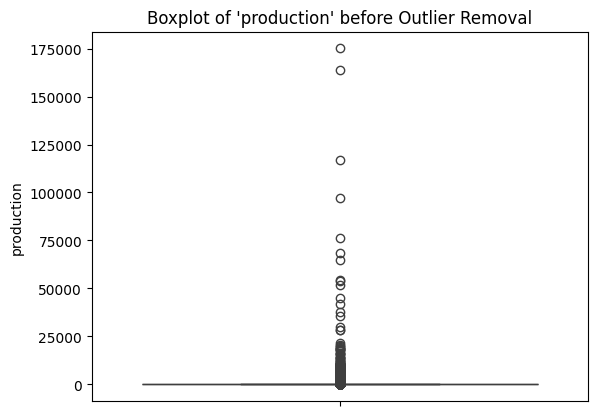

IQR: 47.20
Lower_Fence: -70.80
Upper_Fence: 118.00

Display Outliers
           date        state     district         crop_type  crop_species  \
0      1/1/2017        Johor   Batu Pahat        cash_crops       cassava   
3      1/1/2017        Johor   Batu Pahat        cash_crops  sweet_potato   
4      1/1/2017        Johor   Batu Pahat        cash_crops           yam   
7      1/1/2017        Johor   Batu Pahat             fruit        banana   
8      1/1/2017        Johor   Batu Pahat             fruit      cempedak   
...         ...          ...          ...               ...           ...   
10960  1/1/2017   Terengganu        Setiu         vegetable       pumpkin   
10962  1/1/2017   Terengganu        Setiu         vegetable    red_chilli   
10967  1/1/2017  W.P. Labuan  W.P. Labuan             fruit        banana   
10984  1/1/2017  W.P. Labuan  W.P. Labuan  industrial_crops       coconut   
10997  1/1/2017  W.P. Labuan  W.P. Labuan         vegetable       mustard   

      

In [ ]:
# Display a BoxPlot
sns.boxplot(Crops_District_Production_df['production'])
plt.title("Boxplot of 'production' before Outlier Removal")  # Add title
plt.show()

# Compute the Interquartile Range (IQR)
Q1 = Crops_District_Production_df['production'].quantile(0.25)
Q3 = Crops_District_Production_df['production'].quantile(0.75)
IQR = Q3 - Q1
print ("IQR: %.2f" %IQR)

# Calculate the Lower and Upper Fence
Lower_Fence = Q1 - (1.5 * IQR)
print ("Lower_Fence: %.2f" %Lower_Fence)
Upper_Fence = Q3 + (1.5 * IQR)
print ("Upper_Fence: %.2f" %Upper_Fence)

# Display Outliers and Filtering Out the Outliers
print("\nDisplay Outliers")
print (Crops_District_Production_df[((Crops_District_Production_df["production"] < Lower_Fence) | (Crops_District_Production_df["production"] > Upper_Fence))])

# display data with outliers filtered out, use ~ to filter
print("\nDisplay data without outliers")
print (Crops_District_Production_df[~((Crops_District_Production_df["production"] < Lower_Fence) | (Crops_District_Production_df["production"] > Upper_Fence))])

In [ ]:
# Remove outliers
Crops_District_Production_remOutliers = Crops_District_Production_df[~((Crops_District_Production_df["production"] < Lower_Fence) |
                                                                       (Crops_District_Production_df["production"] > Upper_Fence))].reset_index(drop=True)
print(f"Data shape after removing outliers: {Crops_District_Production_remOutliers.shape}")

Data shape after removing outliers: (8973, 6)


In [ ]:
# Recompute IQR on cleaned data
Q1b = Crops_District_Production_remOutliers['production'].quantile(0.25)
Q3b = Crops_District_Production_remOutliers['production'].quantile(0.75)
IQRb = Q3b - Q1b
print ("IQRb: %.2f" %IQRb)

# Calculate the Lower and Upper Fence
Lower_Fence_b = Q1b - (1.5 * IQRb)
print ("Lower_Fence: %.2f" %Lower_Fence_b)
Upper_Fence_b = Q3b + (1.5 * IQRb)
print ("Upper_Fence: %.2f" %Upper_Fence_b)

IQRb: 8.22
Lower_Fence: -12.33
Upper_Fence: 20.55


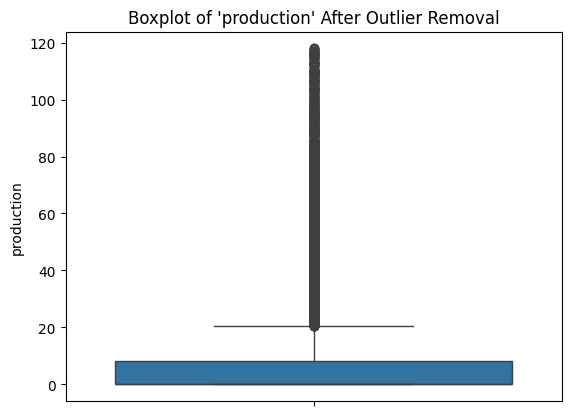

In [ ]:
# Boxplot for data after removing outliers
sns.boxplot(Crops_District_Production_remOutliers['production'])

plt.title("Boxplot of 'production' After Outlier Removal")  # Add title
plt.show()

In [ ]:
# Check condition based on the firstly calculated IQR → results return empty df
# Display Outliers and Filtering Out the Outliers
print("\nDisplay Outliers")
print (Crops_District_Production_remOutliers[((Crops_District_Production_remOutliers["production"] < Lower_Fence) | (Crops_District_Production_remOutliers["production"] > Upper_Fence))])


Display Outliers
Empty DataFrame
Columns: [date, state, district, crop_type, crop_species, production]
Index: []


In [ ]:
# Check condition based on the newly calculated IQR → results return 5 rows with outliers
print("\nDisplay Outliers")
print (Crops_District_Production_remOutliers[((Crops_District_Production_remOutliers["production"] < Lower_Fence_b) | (Crops_District_Production_remOutliers["production"] > Upper_Fence_b))])


Display Outliers
          date        state     district   crop_type          crop_species  \
5     1/1/2017        Johor   Batu Pahat       fruit                dokong   
20    1/1/2017        Johor   Batu Pahat       herbs  fragrant_lemon_grass   
44    1/1/2017        Johor   Batu Pahat      spices      pink_cone_ginger   
48    1/1/2017        Johor   Batu Pahat   vegetable          bottle_gourd   
54    1/1/2017        Johor   Batu Pahat   vegetable           french_bean   
...        ...          ...          ...         ...                   ...   
8934  1/1/2017   Terengganu        Setiu   vegetable             long_bean   
8938  1/1/2017  W.P. Labuan  W.P. Labuan  cash_crops               cassava   
8948  1/1/2017  W.P. Labuan  W.P. Labuan       fruit             jackfruit   
8964  1/1/2017  W.P. Labuan  W.P. Labuan   vegetable       chinese_spinach   
8972  1/1/2017  W.P. Labuan  W.P. Labuan   vegetable         water_spinach   

      production  
5       28.00000  
20     

Remove outliers of 'Mean temperature-Min (oC)', 'Mean temperature-Max (oC)', 'Rainfall-Total (mm)', 'Rainfall-No. of days', 'Mean relative humidity (%)'

In [ ]:
print(f"Original data shape: {Weather_df.shape}")

Original data shape: (34, 9)


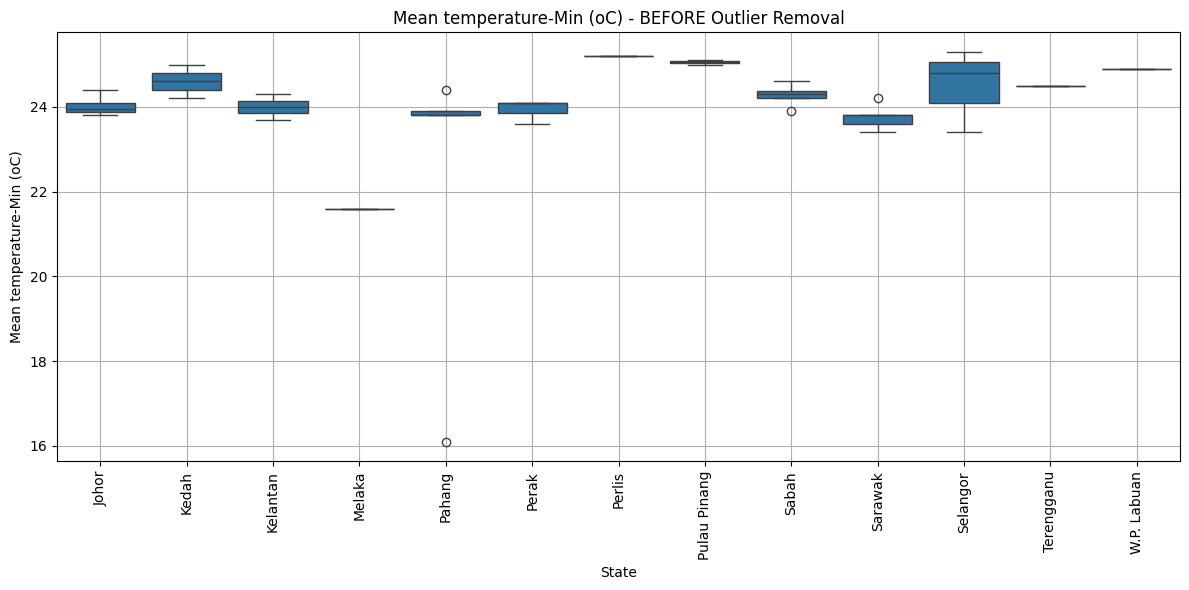

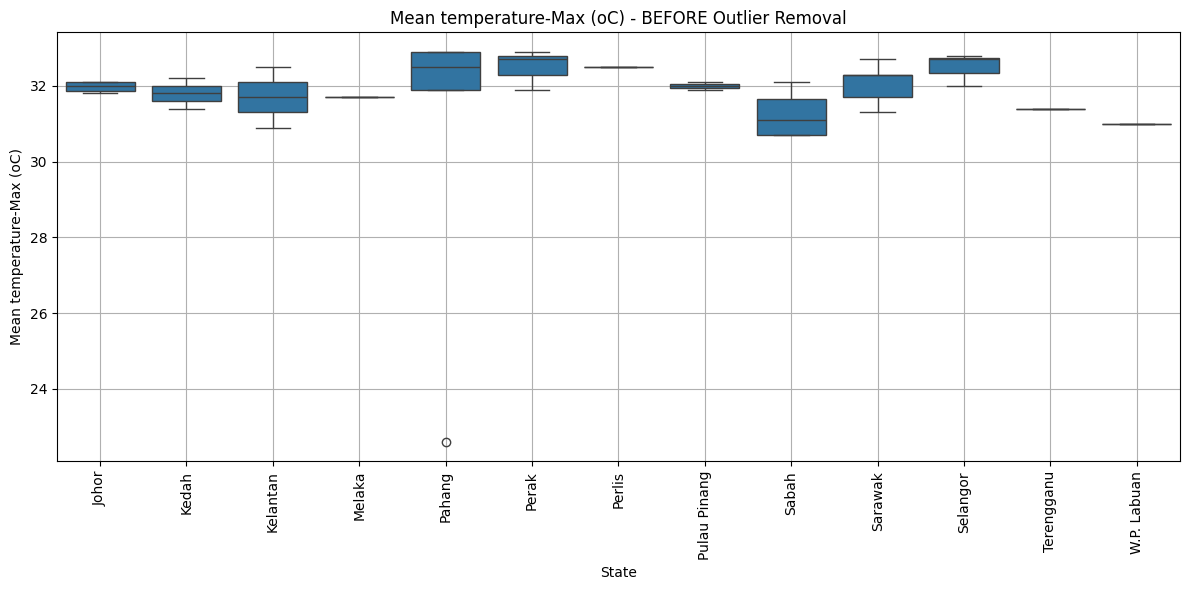

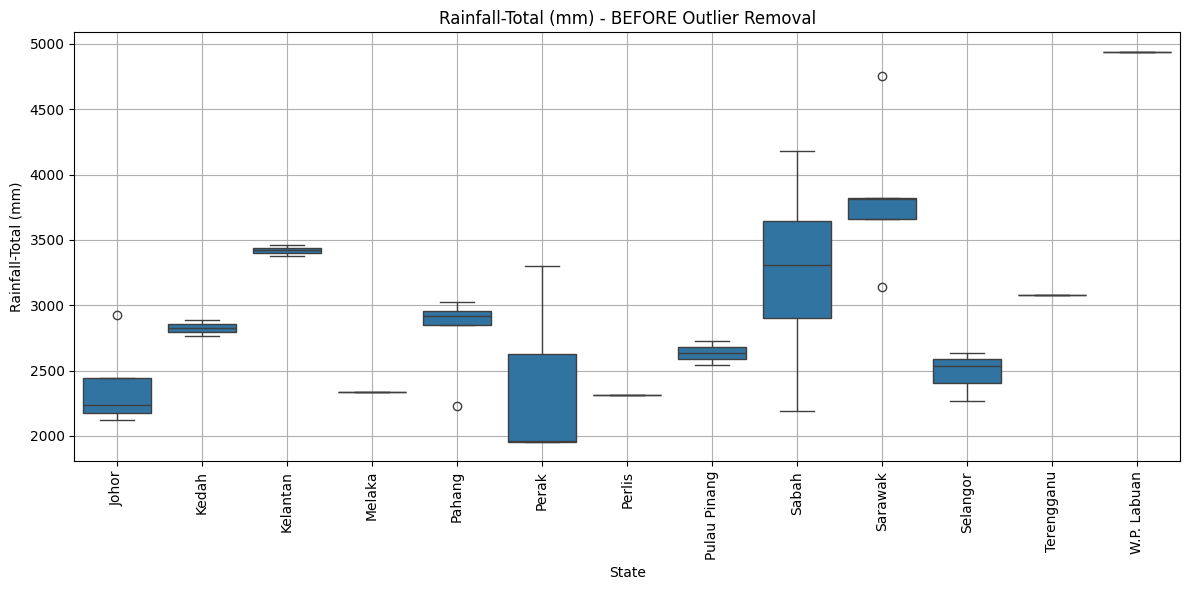

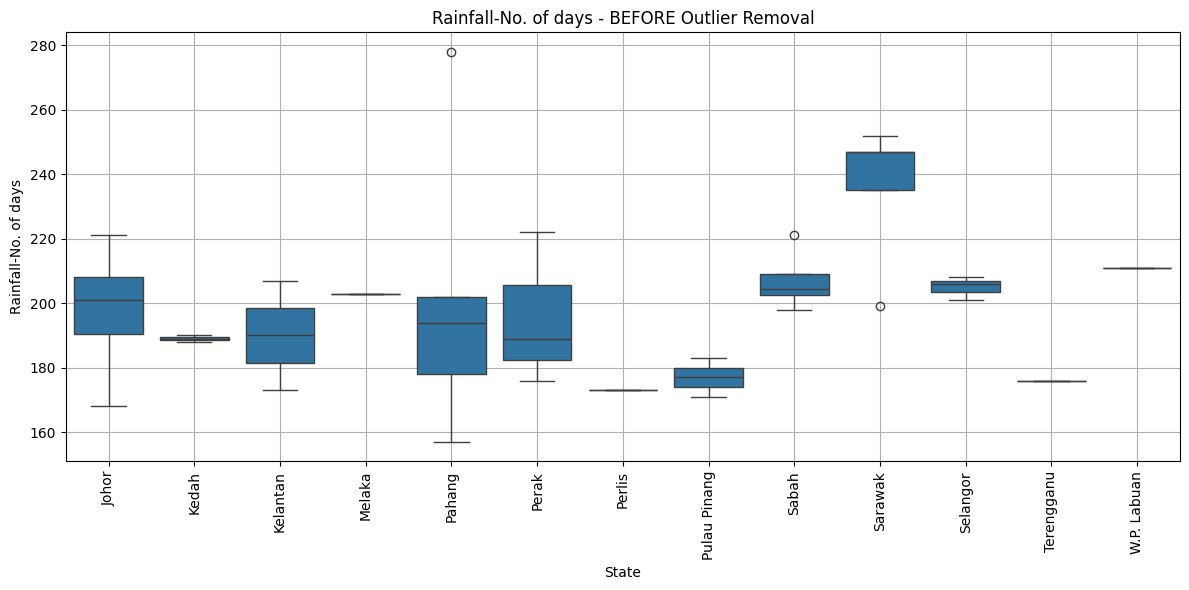

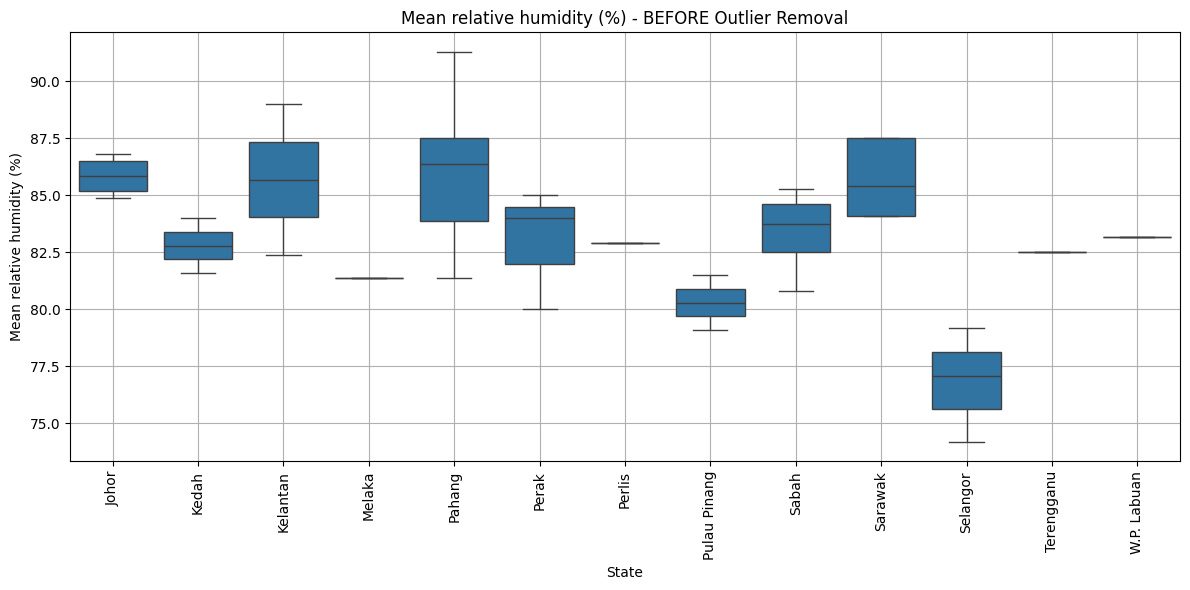


State: Johor
Mean temperature-Min (oC) | Q1: 23.88, Q3: 24.10, IQR: 0.23, LF: 23.54, UF: 24.44
Mean temperature-Max (oC) | Q1: 31.88, Q3: 32.10, IQR: 0.23, LF: 31.54, UF: 32.44
Rainfall-Total (mm) | Q1: 2172.05, Q3: 2439.88, IQR: 267.82, LF: 1770.31, UF: 2841.61
Rainfall-No. of days | Q1: 183.00, Q3: 201.00, IQR: 18.00, LF: 156.00, UF: 228.00
Mean relative humidity (%) | Q1: 85.10, Q3: 85.85, IQR: 0.75, LF: 83.97, UF: 86.97

State: Kedah
Mean temperature-Min (oC) | Q1: 24.40, Q3: 24.80, IQR: 0.40, LF: 23.80, UF: 25.40
Mean temperature-Max (oC) | Q1: 31.60, Q3: 32.00, IQR: 0.40, LF: 31.00, UF: 32.60
Rainfall-Total (mm) | Q1: 2793.60, Q3: 2854.40, IQR: 60.80, LF: 2702.40, UF: 2945.60
Rainfall-No. of days | Q1: 188.50, Q3: 189.50, IQR: 1.00, LF: 187.00, UF: 191.00
Mean relative humidity (%) | Q1: 82.20, Q3: 83.40, IQR: 1.20, LF: 80.40, UF: 85.20

State: Kelantan
Mean temperature-Min (oC) | Q1: 23.85, Q3: 24.15, IQR: 0.30, LF: 23.40, UF: 24.60
Mean temperature-Max (oC) | Q1: 31.30, Q3: 32

In [ ]:
# Standardize state name
Weather_df['State'] = Weather_df['State'].replace({'Wilayah Persekutuan Labuan': 'W.P. Labuan'})

# Convert to numeric
numeric_cols = [
    'Mean temperature-Min (oC)',
    'Mean temperature-Max (oC)',
    'Rainfall-Total (mm)',
    'Rainfall-No. of days',
    'Mean relative humidity (%)'
]

Weather_df[numeric_cols] = Weather_df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Plot BEFORE outlier removal
for col in numeric_cols:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=Weather_df, x='State', y=col)
    plt.xticks(rotation=90)
    plt.title(f'{col} - BEFORE Outlier Removal')
    plt.tight_layout()
    plt.grid(True)
    plt.show()

# Function to remove outliers by IQR (grouped by state)
def remove_outliers_iqr_grouped(df, group_col, numeric_cols):
    all_outliers = []

    def filter_group(group_name, group_df):
        outliers_in_group = pd.DataFrame()
        print(f"\nState: {group_name}")  # Print state name once

        for col in numeric_cols:
            Q1 = group_df[col].quantile(0.25)
            Q3 = group_df[col].quantile(0.75)
            IQR = Q3 - Q1
            LF = Q1 - 1.5 * IQR
            UF = Q3 + 1.5 * IQR

            print(f"{col} | Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}, LF: {LF:.2f}, UF: {UF:.2f}")

            # Identify outliers
            outliers = group_df[(group_df[col] < LF) | (group_df[col] > UF)]
            outliers_in_group = pd.concat([outliers_in_group, outliers])

            # Remove outliers
            group_df = group_df[(group_df[col] >= LF) & (group_df[col] <= UF)]

        all_outliers.append(outliers_in_group)
        return group_df

    # Custom groupby loop
    cleaned_groups = []
    for group_name, group_df in df.groupby(group_col):
        cleaned_group = filter_group(group_name, group_df)
        cleaned_groups.append(cleaned_group)

    cleaned_df = pd.concat(cleaned_groups, ignore_index=True)
    all_outliers_df = pd.concat(all_outliers, ignore_index=True)

    print("\nTOTAL OUTLIERS FOUND:", len(all_outliers_df))
    print("Display Outliers")
    print(all_outliers_df)

    return cleaned_df

# Apply the function
weather_remOutliers = remove_outliers_iqr_grouped(Weather_df, 'State', numeric_cols)


In [ ]:
print("\nDisplay data without outliers")
print(weather_remOutliers)


Display data without outliers
           State                   Selected meteorological station   \
0          Johor                                             Kluang   
1          Johor                                         Batu Pahat   
2          Johor                                            Mersing   
3          Kedah                                         Alor Setar   
4          Kedah                                     Pulau Langkawi   
5       Kelantan                                         Kota Bharu   
6       Kelantan                                         Kuala Krai   
7         Melaka                                             Melaka   
8         Pahang                                            Kuantan   
9         Pahang                               Batu Embun, Jerantut   
10        Pahang                                       Muadzam Shah   
11         Perak                                               Ipoh   
12         Perak                              

In [ ]:
print(f"Data shape after removing outliers by state: {weather_remOutliers.shape}")


Data shape after removing outliers by state: (28, 9)


In [ ]:
# Recompute IQRs after outlier removal & check for remaining outliers
remaining_outliers = pd.DataFrame()
print("\nRecomputing IQRs AFTER outlier removal:")
for state_name, group in weather_remOutliers.groupby("State"):
    print(f"\nState: {state_name}")
    for col in numeric_cols:
        Q1b = group[col].quantile(0.25)
        Q3b = group[col].quantile(0.75)
        IQRb = Q3b - Q1b
        LFb = Q1b - 1.5 * IQRb
        UFb = Q3b + 1.5 * IQRb

        col_short = col.split('(')[0].strip()
        print(f"{col_short} | New Q1: {Q1b:.2f}, Q3: {Q3b:.2f}, IQR: {IQRb:.2f}, LF: {LFb:.2f}, UF: {UFb:.2f}")

        # Check if any remaining outliers exist
        outlier_check = group[(group[col] < LFb) | (group[col] > UFb)]
        if not outlier_check.empty:
            remaining_outliers = pd.concat([remaining_outliers, outlier_check])

# Final result on remaining outliers
if not remaining_outliers.empty:
    print("\nRemaining Outliers After Removal Based on New IQRs:")
    print(remaining_outliers)
else:
    print("\nNo outliers remain after removal based on new IQRs.")


Recomputing IQRs AFTER outlier removal:

State: Johor
Mean temperature-Min | New Q1: 23.85, Q3: 24.15, IQR: 0.30, LF: 23.40, UF: 24.60
Mean temperature-Max | New Q1: 31.85, Q3: 32.00, IQR: 0.15, LF: 31.63, UF: 32.22
Rainfall-Total | New Q1: 2154.10, Q3: 2233.80, IQR: 79.70, LF: 2034.55, UF: 2353.35
Rainfall-No. of days | New Q1: 183.00, Q3: 201.00, IQR: 18.00, LF: 156.00, UF: 228.00
Mean relative humidity | New Q1: 85.10, Q3: 85.85, IQR: 0.75, LF: 83.97, UF: 86.97

State: Kedah
Mean temperature-Min | New Q1: 24.40, Q3: 24.80, IQR: 0.40, LF: 23.80, UF: 25.40
Mean temperature-Max | New Q1: 31.60, Q3: 32.00, IQR: 0.40, LF: 31.00, UF: 32.60
Rainfall-Total | New Q1: 2793.60, Q3: 2854.40, IQR: 60.80, LF: 2702.40, UF: 2945.60
Rainfall-No. of days | New Q1: 188.50, Q3: 189.50, IQR: 1.00, LF: 187.00, UF: 191.00
Mean relative humidity | New Q1: 82.20, Q3: 83.40, IQR: 1.20, LF: 80.40, UF: 85.20

State: Kelantan
Mean temperature-Min | New Q1: 23.85, Q3: 24.15, IQR: 0.30, LF: 23.40, UF: 24.60
Mean

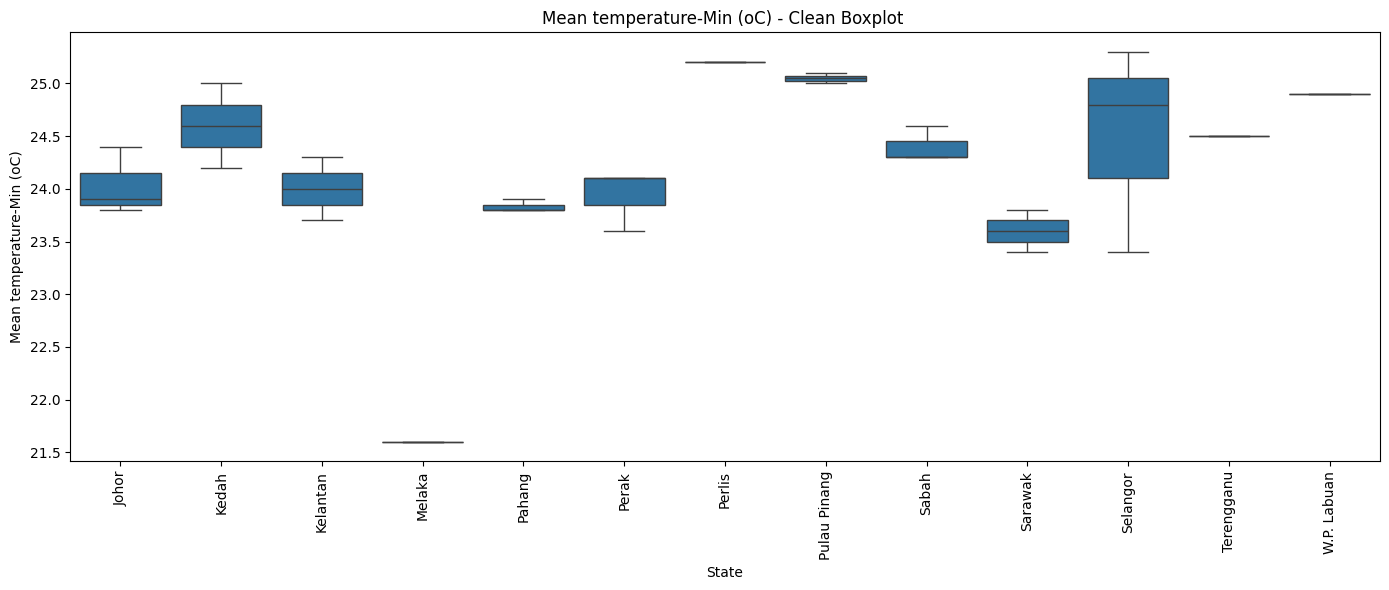

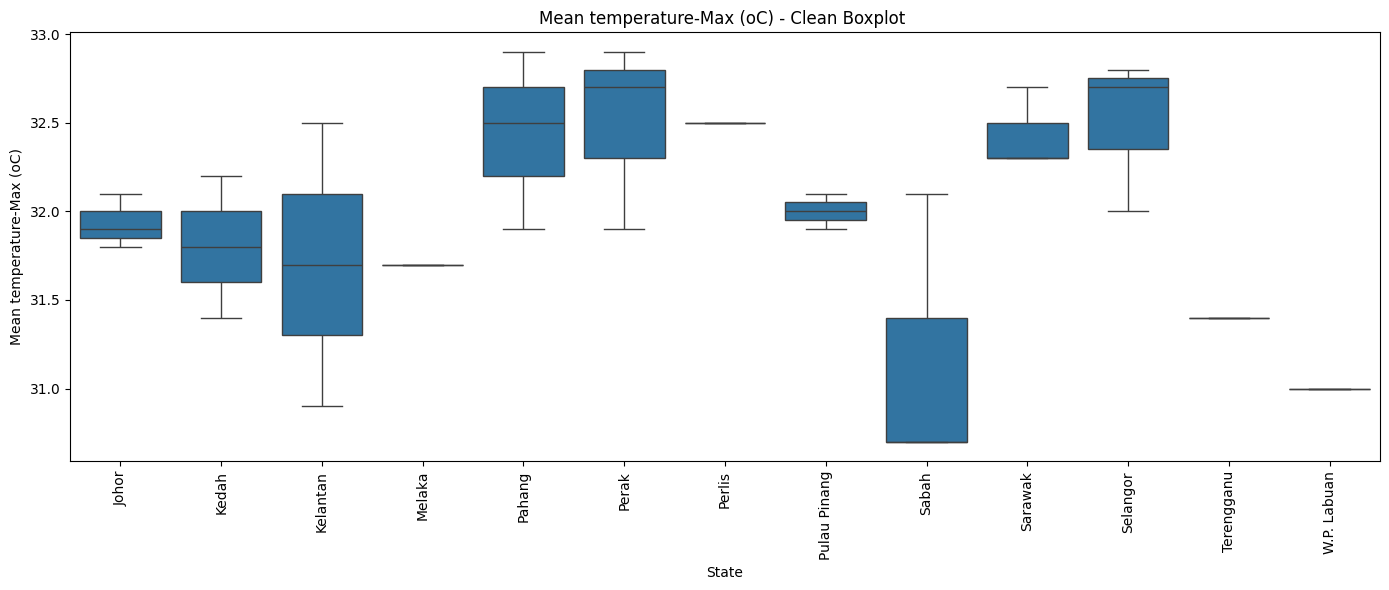

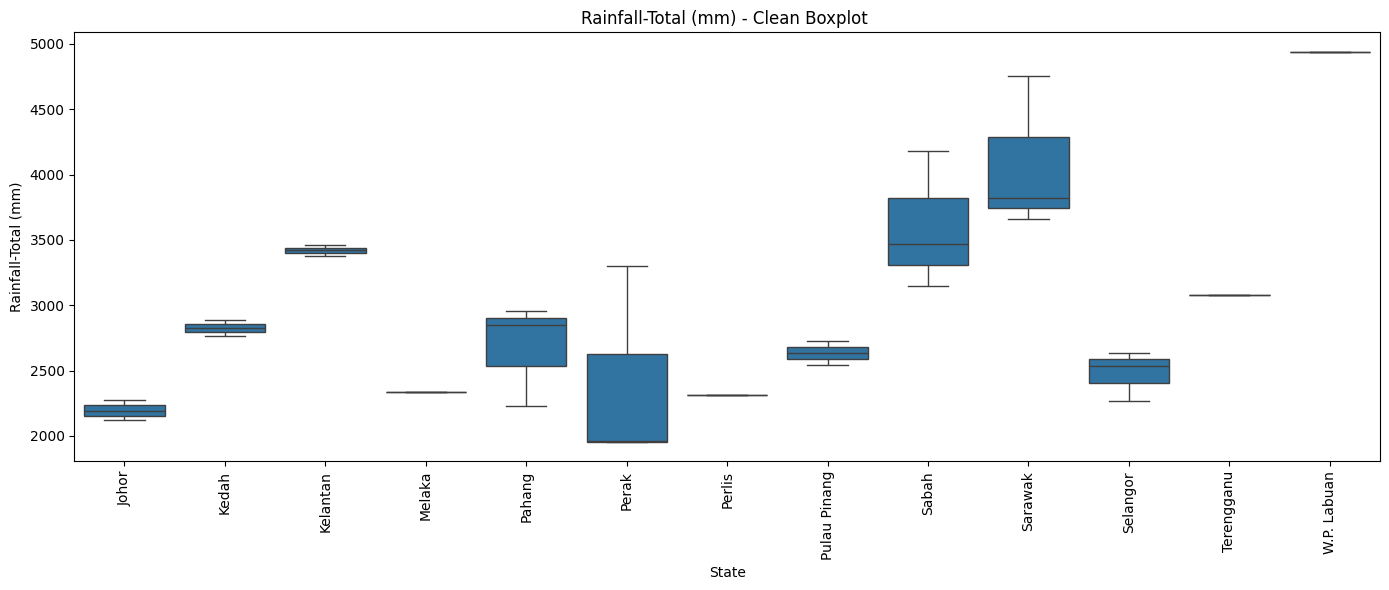

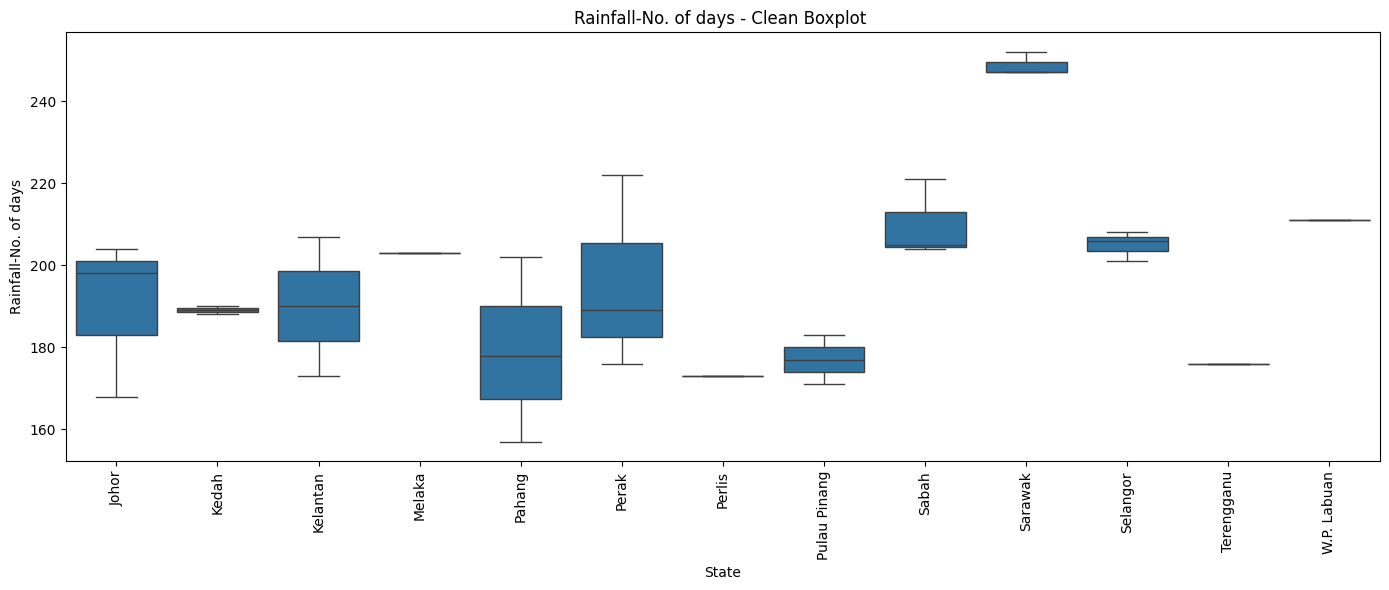

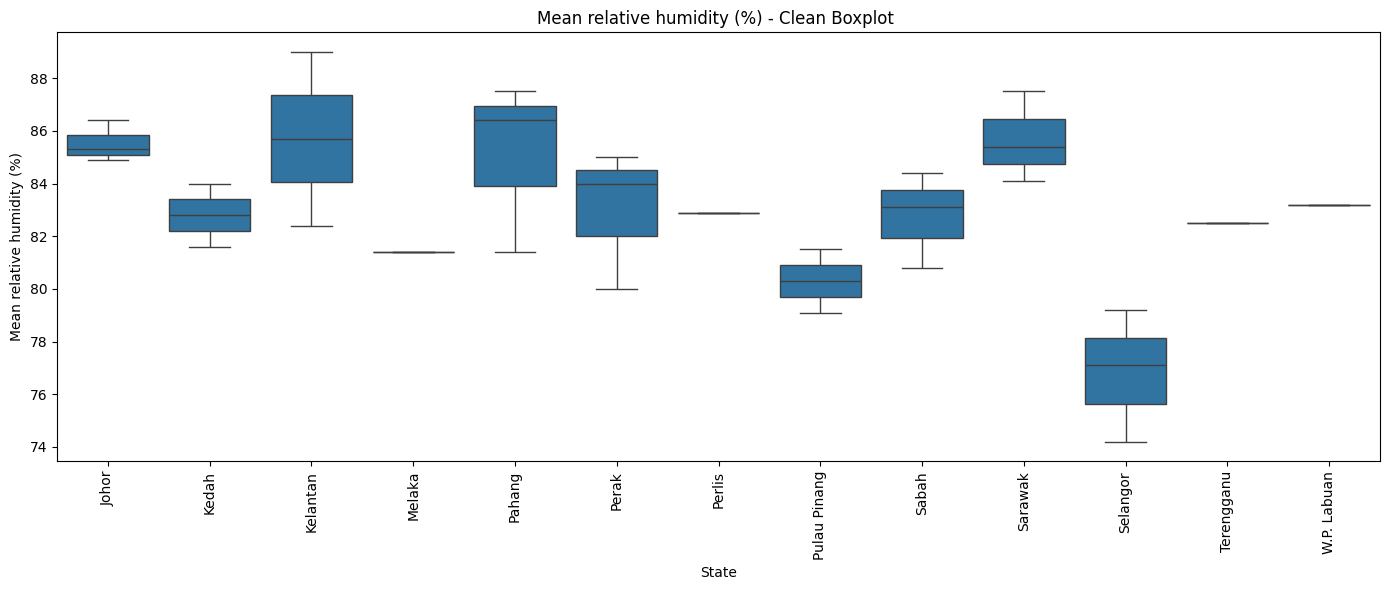

In [ ]:
# Boxplots with outliers hidden
for col in numeric_cols:
    plt.figure(figsize=(14, 6))
    sns.boxplot(data=weather_remOutliers, x='State', y=col, showfliers=False)
    plt.xticks(rotation=90)
    plt.title(f'{col} - Clean Boxplot ')
    plt.tight_layout()
    plt.show()

Remove outliers of planted area

In [ ]:
print(f"Original data shape: {Crops_District_Area_df.shape}")

Original data shape: (10438, 6)


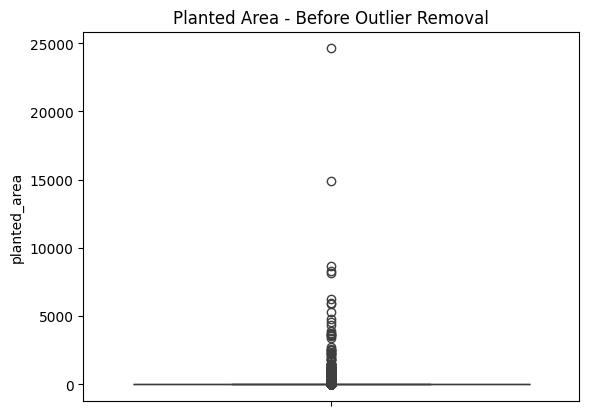

IQR: 9.00
Lower_Fence: -13.50
Upper_Fence: 22.50

Display Outliers
           date        state     district         crop_type  crop_species  \
0      1/1/2017        Johor   Batu Pahat        cash_crops       cassava   
3      1/1/2017        Johor   Batu Pahat        cash_crops  sweet_potato   
4      1/1/2017        Johor   Batu Pahat        cash_crops           yam   
6      1/1/2017        Johor   Batu Pahat             fruit        banana   
7      1/1/2017        Johor   Batu Pahat             fruit      cempedak   
...         ...          ...          ...               ...           ...   
10515  1/1/2017   Terengganu        Setiu        vegetables    red_chilli   
10520  1/1/2017  W.P. Labuan  W.P. Labuan             fruit        banana   
10535  1/1/2017  W.P. Labuan  W.P. Labuan             fruit      rambutan   
10537  1/1/2017  W.P. Labuan  W.P. Labuan  industrial_crops       coconut   
10550  1/1/2017  W.P. Labuan  W.P. Labuan        vegetables       mustard   

       p

In [ ]:
# Plot initial boxplot
sns.boxplot(y=Crops_District_Area_df['planted_area'])
plt.title('Planted Area - Before Outlier Removal')
plt.show()

# Compute IQR
Q1 = Crops_District_Area_df['planted_area'].quantile(0.25)
Q3 = Crops_District_Area_df['planted_area'].quantile(0.75)
IQR = Q3 - Q1
print(f"IQR: {IQR:.2f}")

# Fences
Lower_Fence = Q1 - 1.5 * IQR
Upper_Fence = Q3 + 1.5 * IQR
print(f"Lower_Fence: {Lower_Fence:.2f}")
print(f"Upper_Fence: {Upper_Fence:.2f}")

# Outliers
print("\nDisplay Outliers")
outliers = Crops_District_Area_df[
    (Crops_District_Area_df["planted_area"] < Lower_Fence) |
    (Crops_District_Area_df["planted_area"] > Upper_Fence)
]
print(outliers)

# Data without outliers
area_remOutliers = Crops_District_Area_df[
    ~((Crops_District_Area_df["planted_area"] < Lower_Fence) |
      (Crops_District_Area_df["planted_area"] > Upper_Fence))
]
print("\nData without outliers")
print(area_remOutliers)

In [ ]:
print(f"\nData shape after removing outliers: {area_remOutliers.shape}")


Data shape after removing outliers: (8699, 6)


In [ ]:
# Recompute IQR on cleaned data
Q1b = area_remOutliers['planted_area'].quantile(0.25)
Q3b = area_remOutliers['planted_area'].quantile(0.75)
IQRb = Q3b - Q1b
print ("IQRb: %.2f" %IQRb)

# Calculate the Lower and Upper Fence
Lower_Fence_b = Q1b - (1.5 * IQRb)
print ("Lower_Fence: %.2f" %Lower_Fence_b)
Upper_Fence_b = Q3b + (1.5 * IQRb)
print ("Upper_Fence: %.2f" %Upper_Fence_b)

IQRb: 2.44
Lower_Fence: -3.66
Upper_Fence: 6.10


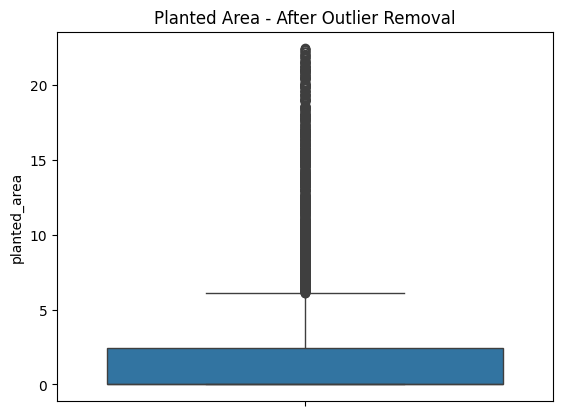

In [ ]:
# Boxplot after outlier removal
sns.boxplot(y=area_remOutliers['planted_area'])
plt.title('Planted Area - After Outlier Removal')
plt.show()

In [ ]:
print("\nDisplay Outliers")
print (area_remOutliers[((area_remOutliers["planted_area"] < Lower_Fence) | (area_remOutliers["planted_area"] > Upper_Fence))])


Display Outliers
Empty DataFrame
Columns: [date, state, district, crop_type, crop_species, planted_area]
Index: []


In [ ]:
print("\nDisplay Outliers")
print (area_remOutliers[((area_remOutliers["planted_area"] < Lower_Fence_b) | (area_remOutliers["planted_area"] > Upper_Fence_b))])


Display Outliers
           date        state     district   crop_type      crop_species  \
9      1/1/2017        Johor   Batu Pahat       fruit            dokong   
10     1/1/2017        Johor   Batu Pahat       fruit      dragon_fruit   
62     1/1/2017        Johor   Batu Pahat      spices  pink_cone_ginger   
76     1/1/2017        Johor   Batu Pahat  vegetables       french_bean   
92     1/1/2017        Johor  Johor Bahru  cash_crops      sweet_potato   
...         ...          ...          ...         ...               ...   
10526  1/1/2017  W.P. Labuan  W.P. Labuan       fruit            durian   
10528  1/1/2017  W.P. Labuan  W.P. Labuan       fruit         jackfruit   
10530  1/1/2017  W.P. Labuan  W.P. Labuan       fruit             mango   
10544  1/1/2017  W.P. Labuan  W.P. Labuan  vegetables   chinese_spinach   
10554  1/1/2017  W.P. Labuan  W.P. Labuan  vegetables     water_spinach   

       planted_area  
9              8.00  
10            14.00  
62             

## 2.0 Data Integration

Merge the dataset Crops_District_Production_remOutliers with area_remOutliers

In [ ]:
# Check data for Crops_District_Production_remoOutliers
print (Crops_District_Production_remOutliers.head(10))

       date  state    district   crop_type       crop_species  production
0  1/1/2017  Johor  Batu Pahat  cash_crops         groundnuts         0.0
1  1/1/2017  Johor  Batu Pahat  cash_crops         sweet_corn         0.0
2  1/1/2017  Johor  Batu Pahat  cash_crops            yambean         0.0
3  1/1/2017  Johor  Batu Pahat  cash_crops  yellow_sugar_cane         0.0
4  1/1/2017  Johor  Batu Pahat       fruit               ciku         0.0
5  1/1/2017  Johor  Batu Pahat       fruit             dokong        28.0
6  1/1/2017  Johor  Batu Pahat       fruit            langsat         0.0
7  1/1/2017  Johor  Batu Pahat       fruit              mango         2.5
8  1/1/2017  Johor  Batu Pahat       fruit         mangosteen         0.0
9  1/1/2017  Johor  Batu Pahat       fruit             pomelo         0.0


In [ ]:
#Check data for area_remoOutliers
print ('\n',area_remOutliers.head(10))


         date  state    district   crop_type       crop_species  planted_area
1   1/1/2017  Johor  Batu Pahat  cash_crops         groundnuts           0.0
2   1/1/2017  Johor  Batu Pahat  cash_crops         sweet_corn           0.0
5   1/1/2017  Johor  Batu Pahat  cash_crops  yellow_sugar_cane           0.0
8   1/1/2017  Johor  Batu Pahat       fruit               ciku           0.0
9   1/1/2017  Johor  Batu Pahat       fruit             dokong           8.0
10  1/1/2017  Johor  Batu Pahat       fruit       dragon_fruit          14.0
15  1/1/2017  Johor  Batu Pahat       fruit            langsat           0.0
16  1/1/2017  Johor  Batu Pahat       fruit              mango           1.5
17  1/1/2017  Johor  Batu Pahat       fruit         mangosteen           0.0
20  1/1/2017  Johor  Batu Pahat       fruit             pomelo           0.0


In [ ]:
# Merge on all matching columns
merged1_df = pd.merge(
    Crops_District_Production_remOutliers,
    area_remOutliers,
    on=["date", "state", "district", "crop_type", "crop_species"]
)
print (merged1_df)

          date        state     district   crop_type       crop_species  \
0     1/1/2017        Johor   Batu Pahat  cash_crops         groundnuts   
1     1/1/2017        Johor   Batu Pahat  cash_crops         sweet_corn   
2     1/1/2017        Johor   Batu Pahat  cash_crops  yellow_sugar_cane   
3     1/1/2017        Johor   Batu Pahat       fruit               ciku   
4     1/1/2017        Johor   Batu Pahat       fruit             dokong   
...        ...          ...          ...         ...                ...   
5423  1/1/2017  W.P. Labuan  W.P. Labuan       fruit          pineapple   
5424  1/1/2017  W.P. Labuan  W.P. Labuan       fruit             pomelo   
5425  1/1/2017  W.P. Labuan  W.P. Labuan       fruit          starfruit   
5426  1/1/2017  W.P. Labuan  W.P. Labuan      spices    calamondin_lime   
5427  1/1/2017  W.P. Labuan  W.P. Labuan      spices        lemon_grass   

      production  planted_area  
0            0.0           0.0  
1            0.0           0.0  


In [ ]:
# Check for duplicates for merged dataset
duplicate_rows =merged1_df[merged1_df.duplicated(keep=False)]
print(duplicate_rows)

Empty DataFrame
Columns: [date, state, district, crop_type, crop_species, production, planted_area]
Index: []


Merge the previously merged dataset with weather_remOutliers for weather data.

In [ ]:
print(weather_remOutliers.columns)

Index(['State', 'Selected meteorological station ',
       'Height above mean sea level in metres', 'Year',
       'Mean temperature-Min (oC)', 'Mean temperature-Max (oC)',
       'Rainfall-Total (mm)', 'Rainfall-No. of days',
       'Mean relative humidity (%)'],
      dtype='object')


In [ ]:
print(merged1_df.columns)

Index(['date', 'state', 'district', 'crop_type', 'crop_species', 'production',
       'planted_area'],
      dtype='object')


In [ ]:
# Clean weather data column names
weather_remOutliers.rename(columns={
    'State': 'state',
    'Selected meteorological station ': 'district'
}, inplace=True)

# Define weather columns
weather_cols = [
    'Mean temperature-Min (oC)',
    'Mean temperature-Max (oC)',
    'Rainfall-Total (mm)',
    'Rainfall-No. of days',
    'Mean relative humidity (%)'
]

# Get clean district-level weather data
weather_district = weather_remOutliers[['state', 'district'] + weather_cols].drop_duplicates()

# Compute state-level statistics: mean for non-rainfall, median for rainfall
rainfall_cols = ['Rainfall-Total (mm)', 'Rainfall-No. of days']
non_rainfall_cols = [col for col in weather_cols if col not in rainfall_cols]

# Mean for non-rainfall columns
weather_state_avg_mean = weather_remOutliers.groupby('state')[non_rainfall_cols].mean().reset_index()

# Median for rainfall columns
weather_state_avg_median = weather_remOutliers.groupby('state')[rainfall_cols].median().reset_index()

# Merge both
weather_state_avg = pd.merge(weather_state_avg_mean, weather_state_avg_median, on='state')

# Merge with production + area data
merged = pd.merge(
    merged1_df,
    weather_district,
    on=['state', 'district'],
    how='left'
)

# Merge with state-level backup
final_merged_df = pd.merge(
    merged,
    weather_state_avg,
    on='state',
    how='inner',
    suffixes=('', '_state_avg')
)

# Fill missing values from state-level medians/means
for col in weather_cols:
    final_merged_df[col] = final_merged_df[col].fillna(final_merged_df[f'{col}_state_avg'])
    final_merged_df.drop(columns=[f'{col}_state_avg'], inplace=True)

# Final output
print(final_merged_df)


          date        state     district   crop_type       crop_species  \
0     1/1/2017        Johor   Batu Pahat  cash_crops         groundnuts   
1     1/1/2017        Johor   Batu Pahat  cash_crops         sweet_corn   
2     1/1/2017        Johor   Batu Pahat  cash_crops  yellow_sugar_cane   
3     1/1/2017        Johor   Batu Pahat       fruit               ciku   
4     1/1/2017        Johor   Batu Pahat       fruit             dokong   
...        ...          ...          ...         ...                ...   
5175  1/1/2017  W.P. Labuan  W.P. Labuan       fruit          pineapple   
5176  1/1/2017  W.P. Labuan  W.P. Labuan       fruit             pomelo   
5177  1/1/2017  W.P. Labuan  W.P. Labuan       fruit          starfruit   
5178  1/1/2017  W.P. Labuan  W.P. Labuan      spices    calamondin_lime   
5179  1/1/2017  W.P. Labuan  W.P. Labuan      spices        lemon_grass   

      production  planted_area  Mean temperature-Min (oC)  \
0            0.0           0.0        

Check for duplicate rows in final_merged_df

In [ ]:
duplicate_rows = final_merged_df[final_merged_df.duplicated(keep=False)]
print(duplicate_rows)

Empty DataFrame
Columns: [date, state, district, crop_type, crop_species, production, planted_area, Mean temperature-Min (oC), Mean temperature-Max (oC), Rainfall-Total (mm), Rainfall-No. of days, Mean relative humidity (%)]
Index: []


## 3.0 Exploratory Data Analysis (EDA)

### 3.1 - Univariate Analysis
Understand individual features (one variable at a time)

**A. Check Missing Value**

This step is to check missing value after merging using isnull().sum(), and we found out that there is no missing values found in *final_merged_df* since we already handle it in **2.Data Integration**.

In [ ]:
# Check for any missing values in the DataFrame
missing_values = final_merged_df.isnull().sum()

# Filter and display only columns with missing values
missing_values = missing_values[missing_values > 0]

# Print the result
if not missing_values.empty:
    print("Columns with missing values:")
    print(missing_values)
else:
    print("No missing values found in final_merged_df.")

No missing values found in final_merged_df.


**B. Summary Statistic**

Summary statistics help us understand the overall distribution of the data by providing key metrics such as the total count, mean, standard deviation, minimum, maximum, first quartile, median, and third quartile.

In [ ]:
# Summary Statistics
final_merged_df.describe()

,production,planted_area,Mean temperature-Min (oC),Mean temperature-Max (oC),Rainfall-Total (mm),Rainfall-No. of days,Mean relative humidity (%)
count,5180.000000,5180.000000,5180.000000,5180.000000,5180.000000,5180.000000,5180.000000
mean,8.056609,1.878861,24.120058,31.935026,3043.823243,203.169691,83.551705
std,19.293253,4.022792,0.494515,0.528489,625.064246,23.681716,2.334849
min,0.000000,0.000000,21.600000,30.700000,1957.400000,168.000000,76.833333
25%,0.000000,0.000000,23.833333,31.700000,2536.600000,189.000000,82.766667
50%,0.000000,0.000000,24.033333,31.933333,3074.400000,198.000000,83.000000
75%,4.000000,1.600000,24.500000,32.433333,3467.200000,206.000000,85.666667
max,118.000000,22.400000,25.200000,32.700000,4938.900000,252.000000,89.000000


**C. Feature Distribution**

The purpose of feature distribution is to visualise how each variable spread.

array([[<Axes: title={'center': 'production'}>,
        <Axes: title={'center': 'planted_area'}>,
        <Axes: title={'center': 'Mean temperature-Min (oC)'}>],
       [<Axes: title={'center': 'Mean temperature-Max (oC)'}>,
        <Axes: title={'center': 'Rainfall-Total (mm)'}>,
        <Axes: title={'center': 'Rainfall-No. of days'}>],
       [<Axes: title={'center': 'Mean relative humidity (%)'}>, <Axes: >,
        <Axes: >]], dtype=object)

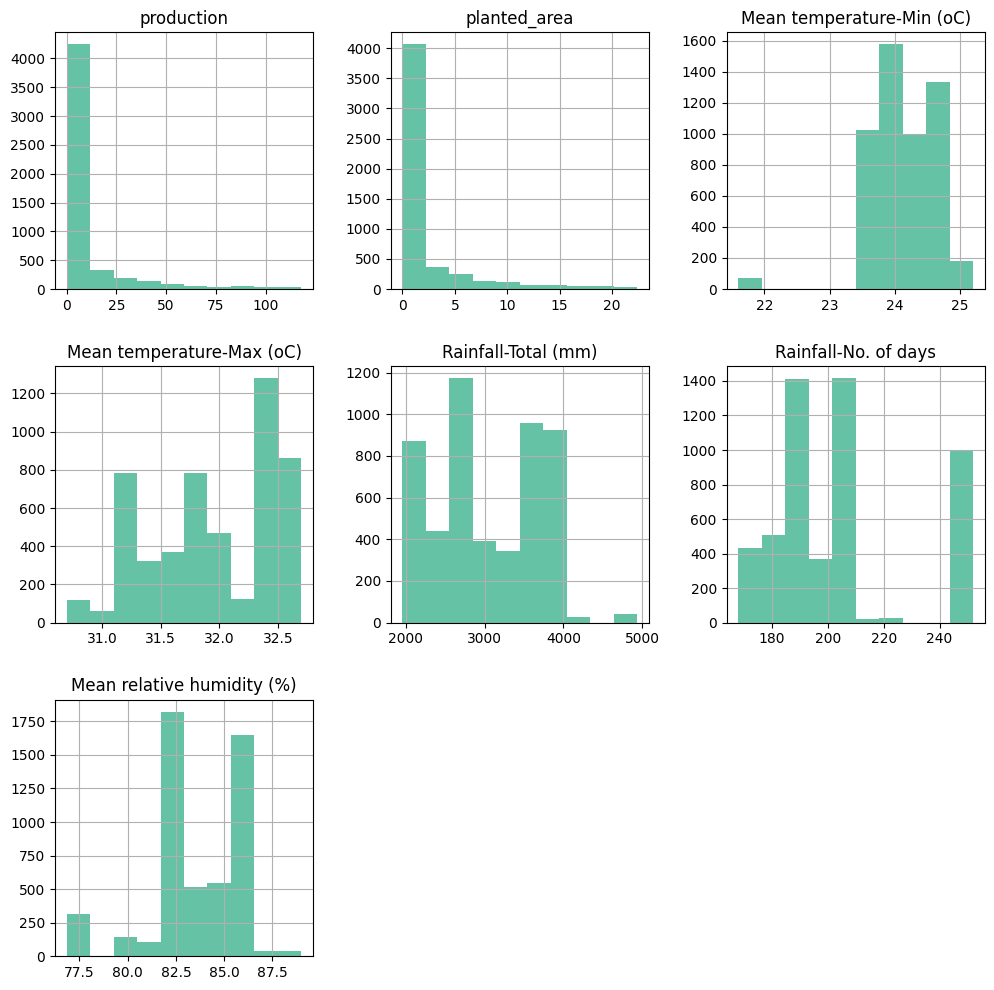

In [ ]:
# Show the distribution of numerical features
sns.set_palette("Set2")
final_merged_df.hist(figsize=(12,12))

**Feature distribution analysis:**
- Production (Highly right-skewed)
- Planted area (Highly right-skewed)
- Mean Temperature – Min (°C) (Approximately normal but slightly left-skewed)
- Mean Temperature – Max (°C) (Multimodal)
- Rainfall – Total (mm) (Multi-modal and moderately skewed)
- Rainfall – Number of Days (Slightly bimodal or tri-modal)
-Mean Relative Humidity (%) (Slightly skewed)

**D. Outlier Detection (Box plot)**

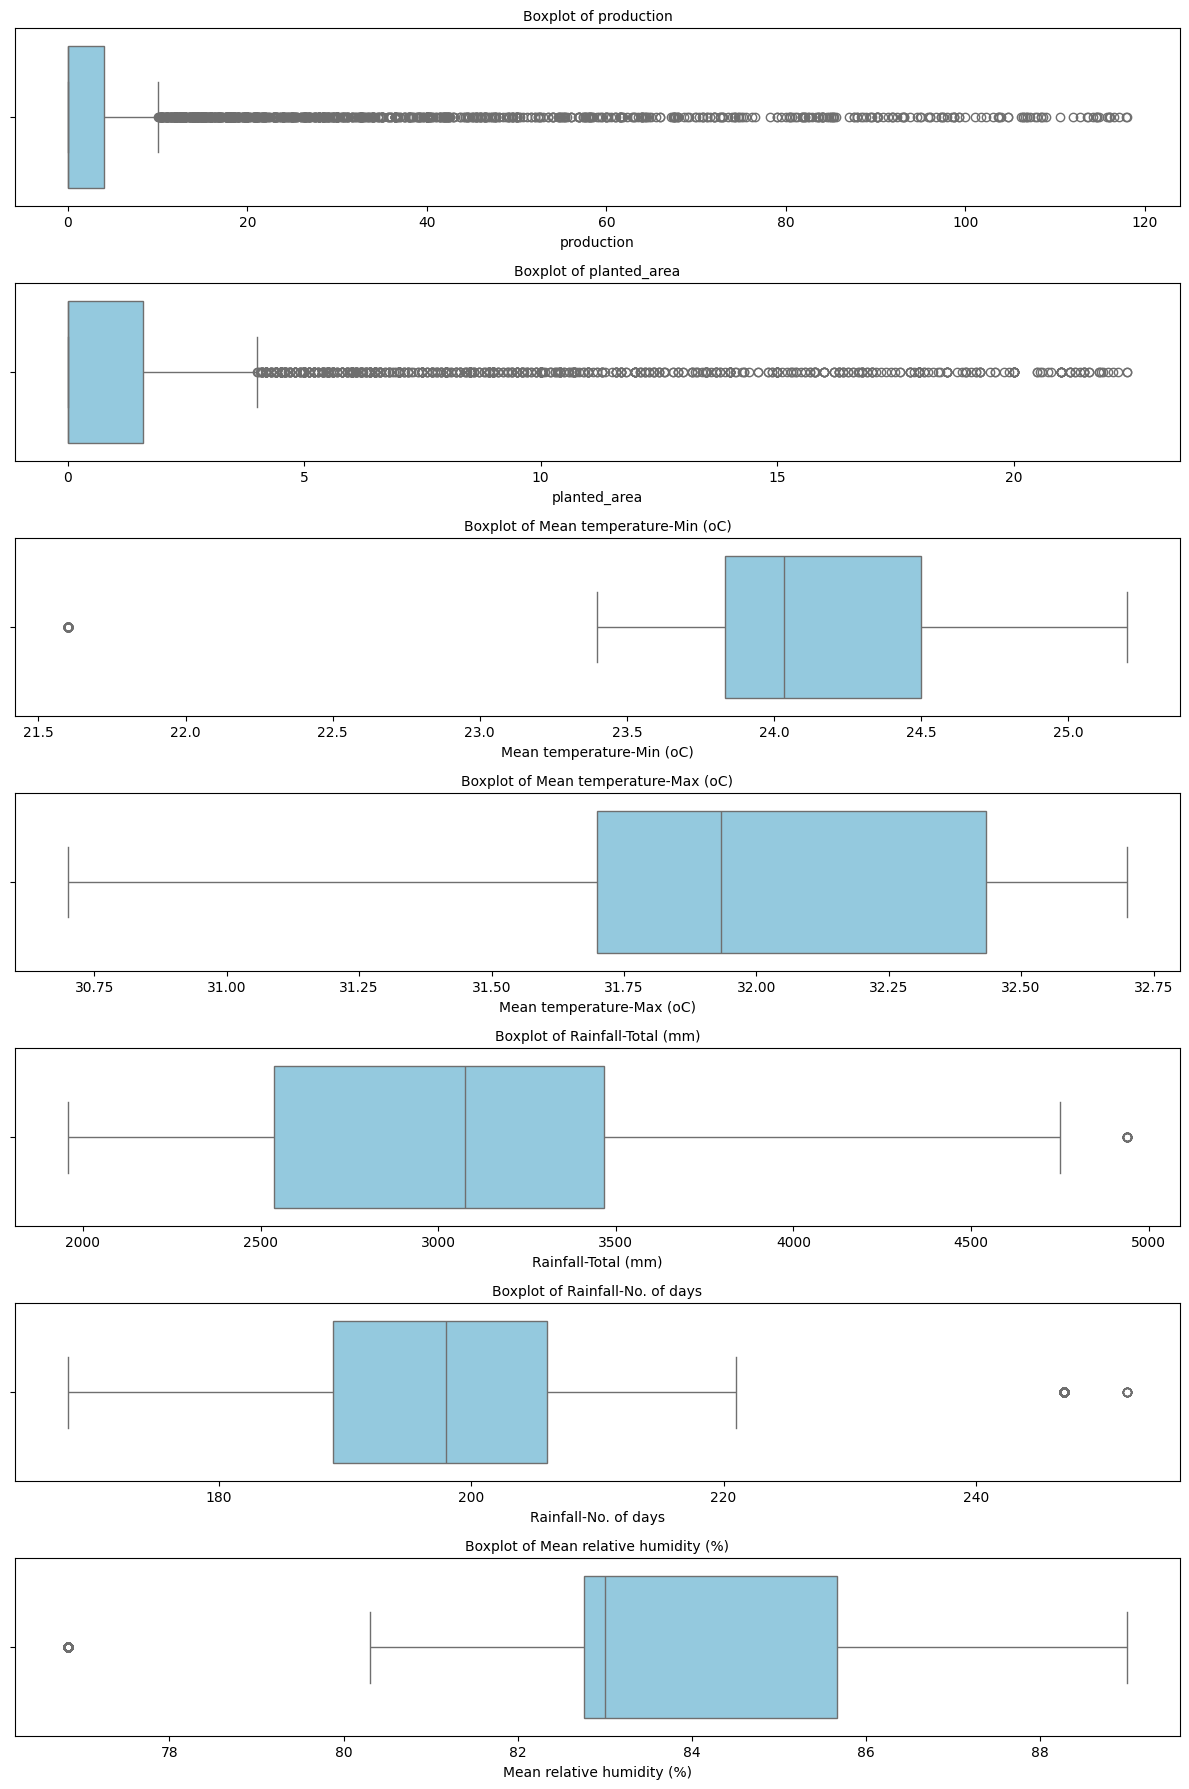

In [ ]:
# List of numerical features
numerical_features = ['production', 'planted_area', 'Mean temperature-Min (oC)',
                      'Mean temperature-Max (oC)', 'Rainfall-Total (mm)', 'Rainfall-No. of days',
                      'Mean relative humidity (%)']

# Create box plots
plt.figure(figsize=(12, 18))

for i, feature in enumerate(numerical_features):
    plt.subplot(len(numerical_features), 1, i + 1)
    sns.boxplot(x=final_merged_df[feature], color='skyblue')
    plt.title(f'Boxplot of {feature}', fontsize=10)

plt.tight_layout()
plt.show()


**Box plot analysis:**
1. Planted area
- **Observation:** Extremely right-skewed with many outliers above the upper whisker. Median is very close to the lower quartile.
- Most districts have small planted areas. A few large-scale districts dominate.
2. Mean Temperature – Min (°C)
- **Observation:** Fairly symmetric distribution. One clear outlier on the low end (~21.5°C).
- Temperature is mostly consistent across records. Outlier might represent unusual weather.
3. Mean Temperature – Max (°C)
- **Observation:** Symmetric distribution, no outliers. Median centered, indicating a normal distribution.
4. Rainfall – Total (mm)
- **Observation:** Distribution is fairly symmetric. One high outlier (~4900 mm).
5. Rainfall – Number of Days
- **Observation:** Near-symmetric, slight right-skew. Few high outliers (>240 days).
- Most regions have 180–220 rainy days. Very rainy districts may behave differently.
6. Mean Relative Humidity (%)
- **Observation:** Slight left-skew. One low outlier (~77%).
- Generally consistent humidity. Outlier may be a dry region.

**Validity of outlier**

As outlier removal was conducted based on states and the merging was also done by districts/states, the outliers shown in the current analysis are valid within their original context, even if they appear as statistical outliers.

**E. Categorical Features Overview**

This helps us to understand the different values present in the categorical columns of our dataset and show how often each value appears. It was visualised in bar plot.

In [ ]:
# Identify categorical columns
categorical_columns = final_merged_df.select_dtypes(include=['object', 'category']).columns.tolist()

# Print value counts for each
for col in categorical_columns:
    print(f"--- {col} ---")
    print(final_merged_df[col].value_counts())
    print("\n")

--- date ---
date
1/1/2017    5180
Name: count, dtype: int64


--- state ---
state
Sarawak         995
Sabah           941
Kedah           663
Johor           470
Perak           445
Pahang          397
Kelantan        380
Terengganu      323
Selangor        318
Pulau Pinang    146
Melaka           70
W.P. Labuan      20
Perlis           12
Name: count, dtype: int64


--- district ---
district
Kudat         92
Keningau      86
Miri          71
Kota Setar    63
Langkawi      60
              ..
Bintulu       18
Simunjan      17
Sarikei       13
Perlis        12
Kuching        9
Name: count, Length: 148, dtype: int64


--- crop_type ---
crop_type
fruit               2116
spices              1088
herbs                840
cash_crops           652
industrial_crops     484
Name: count, dtype: int64


--- crop_species ---
crop_species
ciku              157
starfruit         152
pomelo            146
dragon_fruit      141
lime              136
                 ... 
tenggek_burung     10
corian

<ipython-input-51-14883133dc07>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=final_merged_df, x=col, palette="Set2")


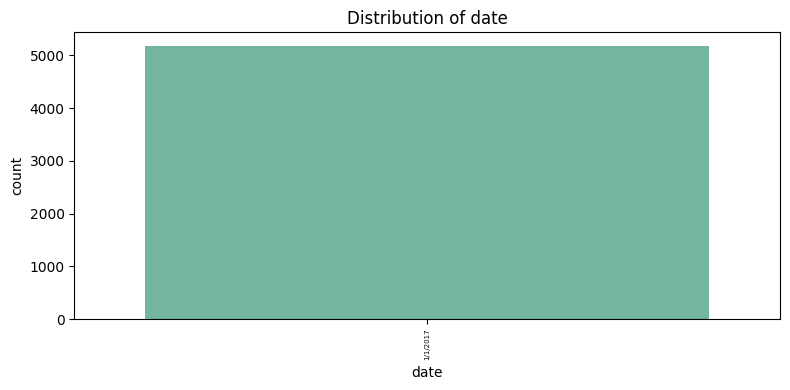

<ipython-input-51-14883133dc07>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=final_merged_df, x=col, palette="Set2")


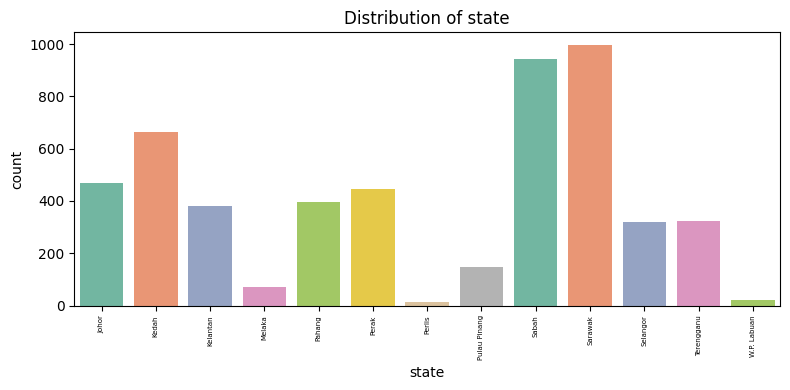

<ipython-input-51-14883133dc07>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=final_merged_df, x=col, palette="Set2")


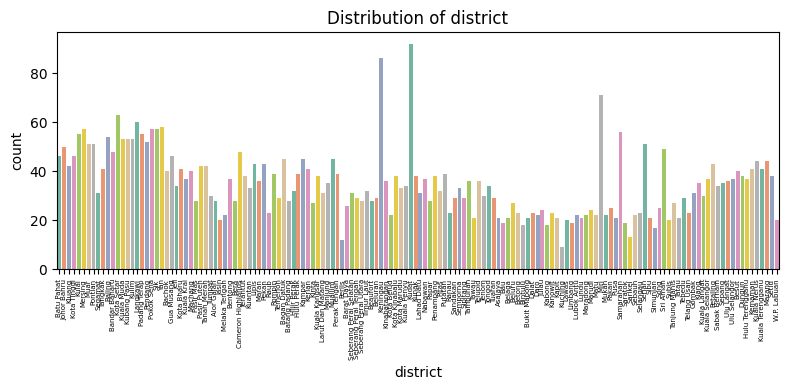

<ipython-input-51-14883133dc07>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=final_merged_df, x=col, palette="Set2")


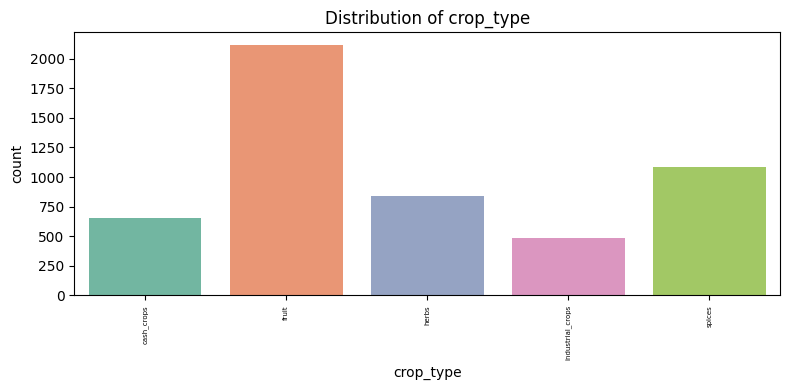

<ipython-input-51-14883133dc07>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=final_merged_df, x=col, palette="Set2")


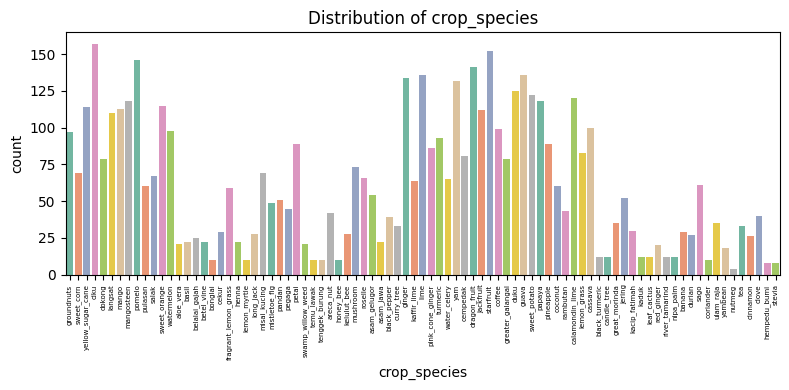

In [ ]:
# Bar plots for categorical features
for col in categorical_columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=final_merged_df, x=col, palette="Set2")
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=90, fontsize=5)  # 👈 Change fontsize here (e.g., 10, 12, etc.)
    plt.tight_layout()
    plt.show()

### 3.2 - Bivariate Analysis

Relationship between one feature and the target

**A. Feature vs. Target Plots**

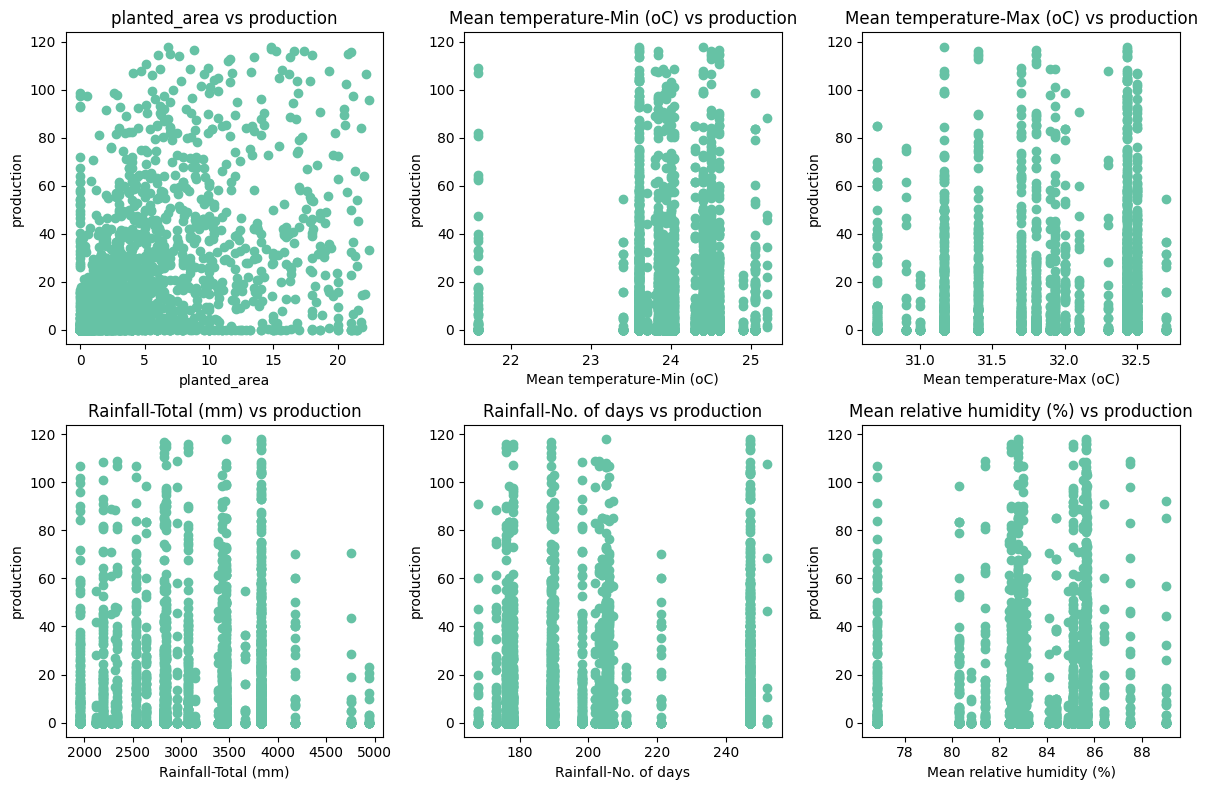

In [ ]:
# Visualisation of relationship between numerical feature and target variable
numerical_feature = ['planted_area', 'Mean temperature-Min (oC)',
                      'Mean temperature-Max (oC)', 'Rainfall-Total (mm)', 'Rainfall-No. of days',
                      'Mean relative humidity (%)']

target_variable = 'production'

# Calculate the number of rows and columns for subplots
num_rows = len(numerical_feature) // 3 + (len(numerical_feature) % 3 > 0)
num_cols = min(len(numerical_feature), 3)

# Create subplots for numerical features
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(12, 4*num_rows))

# Iterate through the numerical features and create scatter plots
for i, feature in enumerate(numerical_feature):
    row = i // num_cols
    col = i % num_cols
    axes[row, col].scatter(final_merged_df[feature], final_merged_df[target_variable])
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel(target_variable)
    axes[row, col].set_title(f"{feature} vs {target_variable}")

# Remove empty subplots if any
if len(numerical_feature) % 3 != 0:
    for j in range(len(numerical_feature), num_rows * num_cols):
        fig.delaxes(axes[j // num_cols, j % num_cols])

# Adjust the spacing between subplots
plt.tight_layout()

# Display the plots
plt.show()

**Feature vs. target plots analysis:**
- There is no strong linear trends visible between most variables and production.
- Production appears to have non-linear, potentially threshold-based or interaction-driven response to environmental variables.
- Data appears clustered, probably due to categorical or regional grouping effects based on districts/states.

### 3.3 - Multivariate Analysis

Relationships among multiple features at once

**A. Pairwise Relationships**

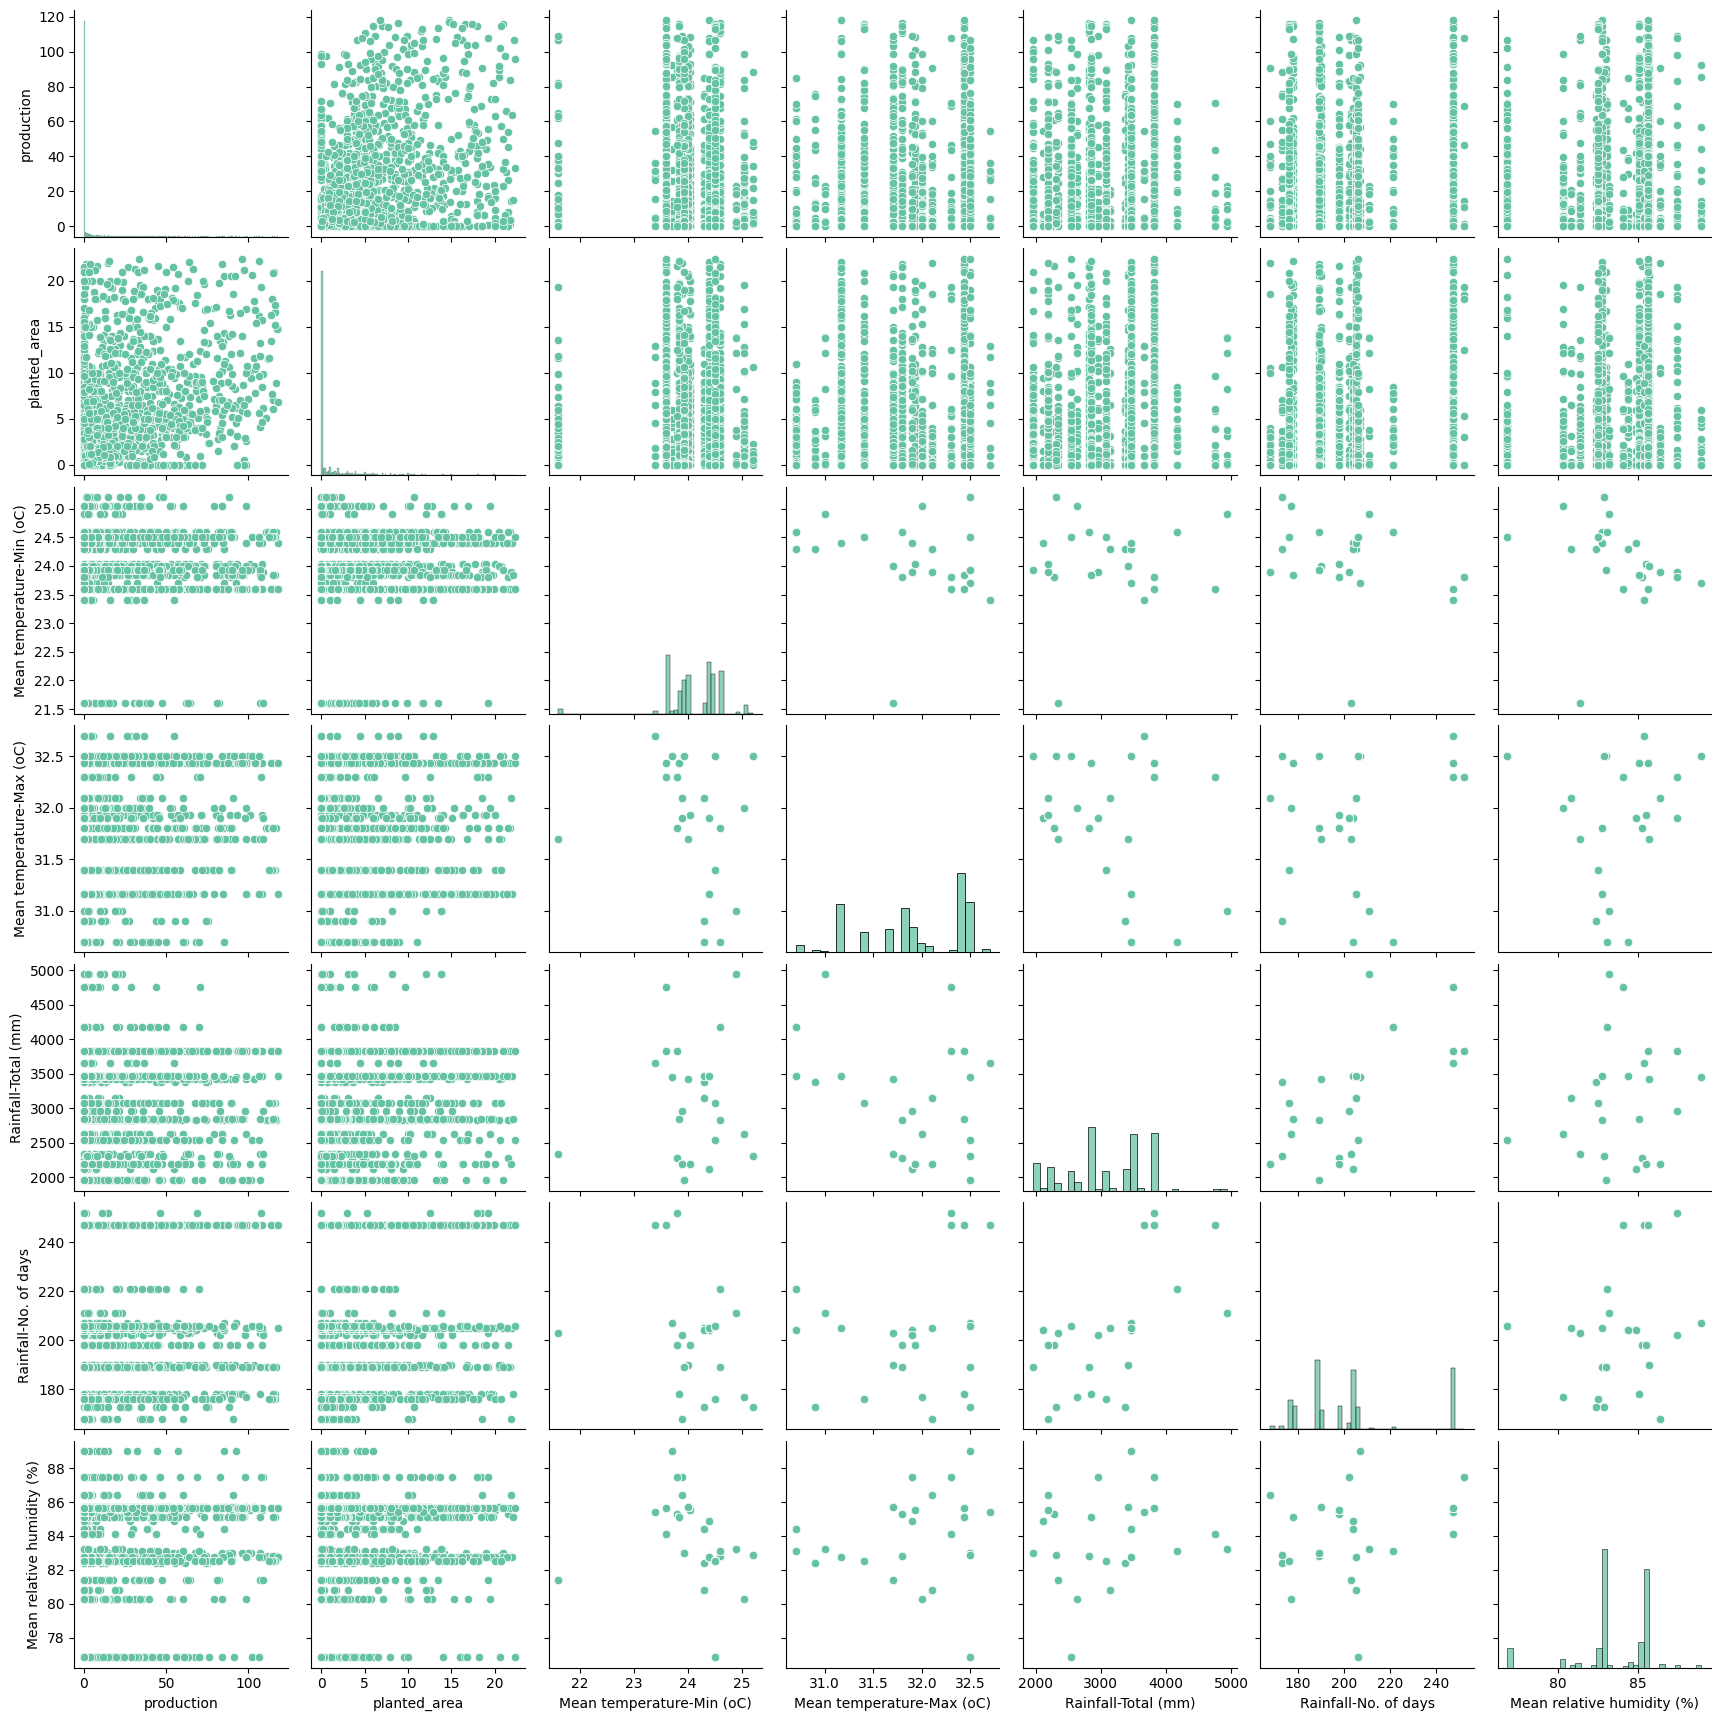

In [ ]:
# Visualize numeric variables
sns.pairplot(final_merged_df)
plt.show()

**Pairplot analysis:**
- Production and planted area show a visible upward trend (positive relationship).
- Most environmental features show scattered plots with production, lacking clear linear patterns, which suggests non-linear relationships or other confounding factors.
- Some plots show horizontal bands, indicating multiple records with the same or very similar values, possibly due to identical weather conditions for several crop types within the same location and year.

**B. Correlation Matrix**

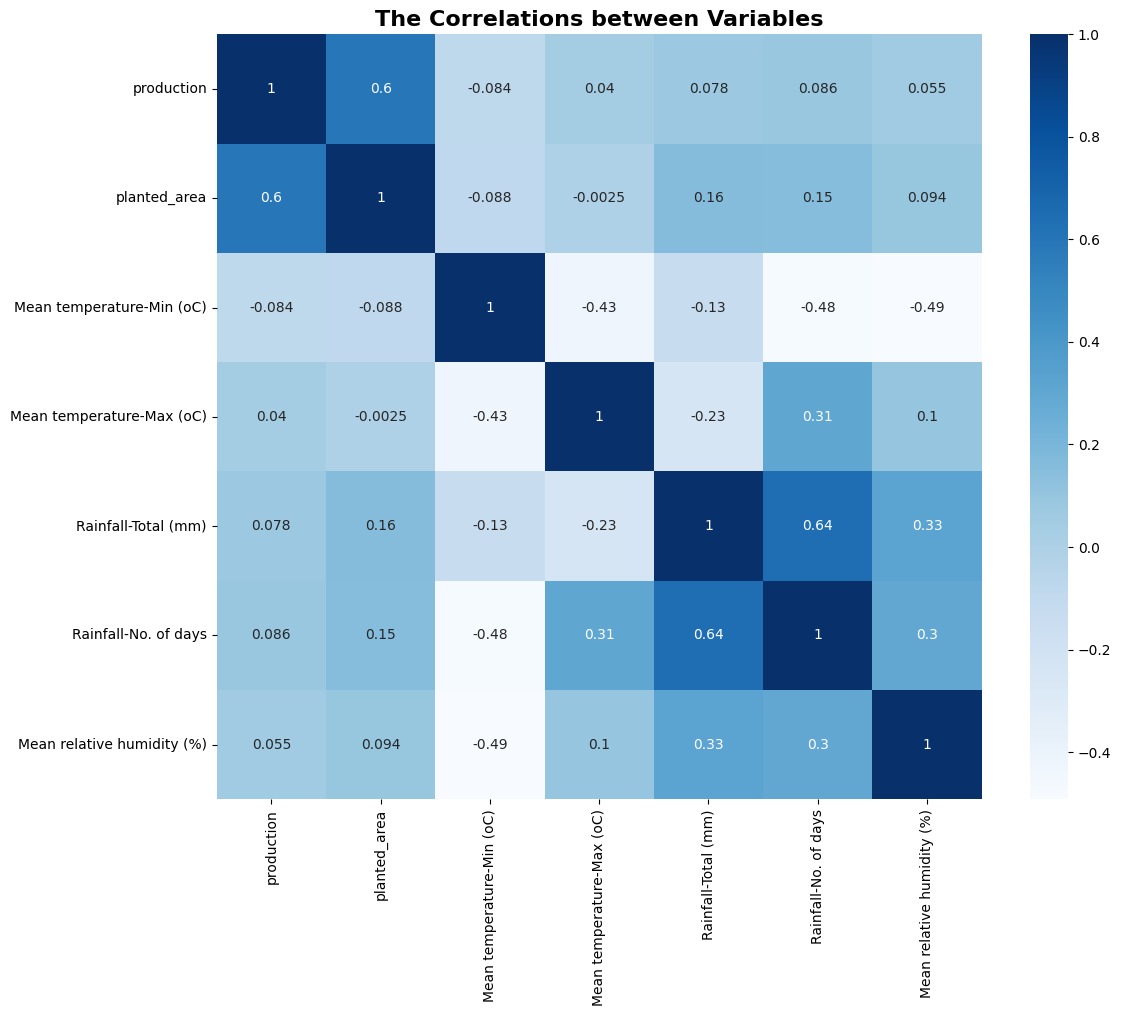

In [ ]:
# Correlation Analysis: Analyze the relationships between numeric variables by calculating correlation coefficients.
selected_columns = ['production', 'planted_area', 'Mean temperature-Min (oC)',
                      'Mean temperature-Max (oC)', 'Rainfall-Total (mm)', 'Rainfall-No. of days',
                      'Mean relative humidity (%)']
corr_matrix = final_merged_df[selected_columns].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='Blues',
            xticklabels=corr_matrix.columns,
            yticklabels=corr_matrix.index,
            square=True,
            cbar=True)

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.title('The Correlations between Variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**Correlation analysis:**

Planted area has a moderate positive correlation with production (r=0.6), showing that it is a significant predator.
All other varaiables show weak correlation with production, including:
- Mean Temperature – Min (°C) (r = -0.084)
- Mean Temperature – Max (°C) (r = 0.04)
- Rainfall – Total (mm) (r = 0.078)
- Rainfall – Number of Days (r = 0.086)
- Mean Relative Humidity (%) (r = 0.055)

### 3.4 - Conclusion for EDA

Given the above findings, we decided to use non-linear machine learning models since linear models rely heavily on strong linear relationships between predictors and target, which are absent in this dataset (except for planted_area). Non-linear models can capture complex interactions and threshold effects among features as well as handle collinearity and non-normal distributions better.

## 4.0 Data Transformation
- Label encoding
- Log Transformation of Skewed Variables
- Transforming Data of Different Scale

In [ ]:
# Separating Categorical Columns from Dataframe using select_dtypes()
df_categorical = final_merged_df.select_dtypes(exclude=[np.number]) # exclude numerical using numpy
print(df_categorical)

          date        state     district   crop_type       crop_species
0     1/1/2017        Johor   Batu Pahat  cash_crops         groundnuts
1     1/1/2017        Johor   Batu Pahat  cash_crops         sweet_corn
2     1/1/2017        Johor   Batu Pahat  cash_crops  yellow_sugar_cane
3     1/1/2017        Johor   Batu Pahat       fruit               ciku
4     1/1/2017        Johor   Batu Pahat       fruit             dokong
...        ...          ...          ...         ...                ...
5175  1/1/2017  W.P. Labuan  W.P. Labuan       fruit          pineapple
5176  1/1/2017  W.P. Labuan  W.P. Labuan       fruit             pomelo
5177  1/1/2017  W.P. Labuan  W.P. Labuan       fruit          starfruit
5178  1/1/2017  W.P. Labuan  W.P. Labuan      spices    calamondin_lime
5179  1/1/2017  W.P. Labuan  W.P. Labuan      spices        lemon_grass

[5180 rows x 5 columns]


In [ ]:
print(df_categorical['date'].unique())

['1/1/2017']


In [ ]:
print(df_categorical['state'].unique())

['Johor' 'Kedah' 'Kelantan' 'Melaka' 'Pahang' 'Perak' 'Perlis'
 'Pulau Pinang' 'Sabah' 'Sarawak' 'Selangor' 'Terengganu' 'W.P. Labuan']


In [ ]:
print(df_categorical['district'].unique())

['Batu Pahat' 'Johor Bahru' 'Kluang' 'Kota Tinggi' 'Kulai' 'Mersing'
 'Muar' 'Pontian' 'Segamat' 'Tangkak' 'Baling' 'Bandar Baharu'
 'Kota Setar' 'Kuala Muda' 'Kubang Pasu' 'Kulim' 'Langkawi' 'Padang Terap'
 'Pendang' 'Pokok Sena' 'Sik' 'Yan' 'Bachok' 'Gua Musang' 'Jeli'
 'Kota Bharu' 'Kuala Krai' 'Machang' 'Pasir Mas' 'Pasir Puteh'
 'Tanah Merah' 'Tumpat' 'Alor Gajah' 'Jasin' 'Melaka Tengah' 'Bentong'
 'Bera' 'Cameron Highlands' 'Jerantut' 'Kuantan' 'Lipis' 'Maran' 'Pekan'
 'Raub' 'Rompin' 'Temerloh' 'Bagan Datuk' 'Batang Padang' 'Hilir Perak'
 'Hulu Perak' 'Kampar' 'Kerian' 'Kinta' 'Kuala Kangsar' 'Larut Dan Matang'
 'Manjung' 'Muallim' 'Perak Tengah' 'Perlis' 'Barat Daya'
 'Seberang Perai Selatan' 'Seberang Perai Tengah' 'Seberang Perai Utara'
 'Timur Laut' 'Beaufort' 'Beluran' 'Keningau' 'Kinabatangan' 'Kota Belud'
 'Kota Kinabalu' 'Kota Marudu' 'Kuala Penyu' 'Kudat' 'Kunak' 'Lahad Datu'
 'Nabawan' 'Papar' 'Penampang' 'Pitas' 'Putatan' 'Ranau' 'Sandakan'
 'Semporna' 'Sipitang' 'Tam

In [ ]:
print(df_categorical['crop_type'].unique())

['cash_crops' 'fruit' 'herbs' 'industrial_crops' 'spices']


In [ ]:
print(df_categorical['crop_species'].unique())

['groundnuts' 'sweet_corn' 'yellow_sugar_cane' 'ciku' 'dokong' 'langsat'
 'mango' 'mangosteen' 'pomelo' 'pulasan' 'salak' 'sweet_orange'
 'watermelon' 'aloe_vera' 'basil' 'belalai_gajah' 'betel_vine' 'bonglai'
 'cekur' 'fragrant_lemon_grass' 'henna' 'lemon_myrtle' 'long_jack'
 'misai_kucing' 'mistletoe_fig' 'pandan' 'pegaga' 'petai'
 'swamp_willow_weed' 'temu_lawak' 'tenggek_burung' 'areca_nut' 'honey_bee'
 'kelulut_bee' 'mushroom' 'roselle' 'asam_gelugor' 'asam_jawa'
 'black_pepper' 'curry_tree' 'ginger' 'kaffir_lime' 'lime'
 'pink_cone_ginger' 'turmeric' 'water_celery' 'yam' 'cempedak'
 'dragon_fruit' 'jackfruit' 'starfruit' 'coffee' 'greater_galangal' 'duku'
 'guava' 'sweet_potato' 'papaya' 'pineapple' 'coconut' 'rambutan'
 'calamondin_lime' 'lemon_grass' 'cassava' 'black_turmeric' 'candle_tree'
 'great_morinda' 'jering' 'kacip_fatimah' 'kaduk' 'leaf_cactus'
 'red_ginger' 'river_tamarind' 'nipa_palm' 'banana' 'durian' 'sago'
 'coriander' 'ulam_raja' 'yambean' 'nutmeg' 'tea' 'cinnamo

Finding frequency of distribution to each column

In [ ]:
print(df_categorical.state.value_counts())

state
Sarawak         995
Sabah           941
Kedah           663
Johor           470
Perak           445
Pahang          397
Kelantan        380
Terengganu      323
Selangor        318
Pulau Pinang    146
Melaka           70
W.P. Labuan      20
Perlis           12
Name: count, dtype: int64


In [ ]:
print(df_categorical.district.value_counts())

district
Kudat         92
Keningau      86
Miri          71
Kota Setar    63
Langkawi      60
              ..
Bintulu       18
Simunjan      17
Sarikei       13
Perlis        12
Kuching        9
Name: count, Length: 148, dtype: int64


In [ ]:
print(df_categorical.crop_type.value_counts())

crop_type
fruit               2116
spices              1088
herbs                840
cash_crops           652
industrial_crops     484
Name: count, dtype: int64


In [ ]:
print(df_categorical.crop_species.value_counts())

crop_species
ciku              157
starfruit         152
pomelo            146
dragon_fruit      141
lime              136
                 ... 
tenggek_burung     10
coriander          10
hempedu_bumi        8
stevia              8
nutmeg              4
Name: count, Length: 85, dtype: int64


### 4.1 - Label Encoding

In [ ]:
# Read Dataset and import LabelEncoder from sklearn.preprocessing package
from sklearn.preprocessing import LabelEncoder

print (final_merged_df.head())

       date  state    district   crop_type       crop_species  production  \
0  1/1/2017  Johor  Batu Pahat  cash_crops         groundnuts         0.0   
1  1/1/2017  Johor  Batu Pahat  cash_crops         sweet_corn         0.0   
2  1/1/2017  Johor  Batu Pahat  cash_crops  yellow_sugar_cane         0.0   
3  1/1/2017  Johor  Batu Pahat       fruit               ciku         0.0   
4  1/1/2017  Johor  Batu Pahat       fruit             dokong        28.0   

   planted_area  Mean temperature-Min (oC)  Mean temperature-Max (oC)  \
0           0.0                       24.4                       31.9   
1           0.0                       24.4                       31.9   
2           0.0                       24.4                       31.9   
3           0.0                       24.4                       31.9   
4           8.0                       24.4                       31.9   

   Rainfall-Total (mm)  Rainfall-No. of days  Mean relative humidity (%)  
0               2118.2 

In [ ]:
# Select Non-Numerical Columns
data_column_category = final_merged_df.select_dtypes (exclude=[np.number]).columns
print (data_column_category)
print (final_merged_df[data_column_category].head())

Index(['date', 'state', 'district', 'crop_type', 'crop_species'], dtype='object')
       date  state    district   crop_type       crop_species
0  1/1/2017  Johor  Batu Pahat  cash_crops         groundnuts
1  1/1/2017  Johor  Batu Pahat  cash_crops         sweet_corn
2  1/1/2017  Johor  Batu Pahat  cash_crops  yellow_sugar_cane
3  1/1/2017  Johor  Batu Pahat       fruit               ciku
4  1/1/2017  Johor  Batu Pahat       fruit             dokong


In [ ]:
# Iterate through column to convert to numeric data using LabelEncoder ()
label_encoder = LabelEncoder()
for i in data_column_category:
    final_merged_df[i] = label_encoder.fit_transform (final_merged_df[i])

In [ ]:
print("Label Encoder Data:")
print(final_merged_df.head())

Label Encoder Data:
   date  state  district  crop_type  crop_species  production  planted_area  \
0     0      0         8          0            31         0.0           0.0   
1     0      0         8          0            72         0.0           0.0   
2     0      0         8          0            84         0.0           0.0   
3     0      0         8          1            16         0.0           0.0   
4     0      0         8          1            23        28.0           8.0   

   Mean temperature-Min (oC)  Mean temperature-Max (oC)  Rainfall-Total (mm)  \
0                       24.4                       31.9               2118.2   
1                       24.4                       31.9               2118.2   
2                       24.4                       31.9               2118.2   
3                       24.4                       31.9               2118.2   
4                       24.4                       31.9               2118.2   

   Rainfall-No. of days 

### 4.2 - Log Transformation of Skewed Variables
We log-transformed highly skewed continuous variables using log1p (i.e., log(1 + x)) to handle zero values, so that skewness is reduced and normality is improved.


In [ ]:
# Duplicate final_merged_df so that the data discretization is not affected by the log transformation.
log_df = final_merged_df.copy()
# Log-transform highly skewed variable
log_df['production'] = np.log1p(log_df['production'])       # log(1 + production)
log_df['planted_area'] = np.log1p(log_df['planted_area'])   # log(1 + area)

### 4.3 - Transforming Data of Different Scale
We perform Standard Scaling and Min-max Scaling for Data Transformation.

In [ ]:
from sklearn import preprocessing
# Perform Standard Scaling and Implement fit_transform () method
std_scale = preprocessing.StandardScaler().fit_transform (final_merged_df)
std_scale_log = preprocessing.StandardScaler().fit_transform (log_df)
scaled_frame_std = pd.DataFrame (std_scale_log, columns = final_merged_df.columns)
scaled_frame_std_log = pd.DataFrame (std_scale_log, columns = log_df.columns)
print (scaled_frame_std_log.head(25))

    date   state  district  crop_type  crop_species  production  planted_area  \
0    0.0 -1.5894 -1.557812  -1.372224     -0.584132   -0.619043     -0.627840   
1    0.0 -1.5894 -1.557812  -1.372224      1.160804   -0.619043     -0.627840   
2    0.0 -1.5894 -1.557812  -1.372224      1.671517   -0.619043     -0.627840   
3    0.0 -1.5894 -1.557812  -0.631795     -1.222524   -0.619043     -0.627840   
4    0.0 -1.5894 -1.557812  -0.631795     -0.924608    1.773511      1.909500   
5    0.0 -1.5894 -1.557812  -0.631795     -0.115979   -0.619043     -0.627840   
6    0.0 -1.5894 -1.557812  -0.631795      0.139378    0.271079      0.430286   
7    0.0 -1.5894 -1.557812  -0.631795      0.181937   -0.619043     -0.627840   
8    0.0 -1.5894 -1.557812  -0.631795      0.692651   -0.619043     -0.627840   
9    0.0 -1.5894 -1.557812  -0.631795      0.735210    0.812600      1.619284   
10   0.0 -1.5894 -1.557812  -0.631795      0.990567   -0.619043     -0.627840   
11   0.0 -1.5894 -1.557812  

## 5.0 Data Discretization
Data discretization involves converting continuous numerical features into categorical bins. This process can simplify data analysis, enhance model interpretability, and reduce computational complexity in some scenarios.

However, since our modeling approach focuses on non-linear algorithms, which naturally handle continuous variables and capture complex relationships, we did not include the discretized data in the final dataset used for training.

In [ ]:
# Using MinMax Scaler Method
minmax_scale = preprocessing.MinMaxScaler().fit_transform (final_merged_df)
minmax_scale_log = preprocessing.MinMaxScaler().fit_transform (log_df)
scaled_frame_minmax = pd.DataFrame (minmax_scale_log, columns = final_merged_df.columns)
scaled_frame_minmax_log = pd.DataFrame (minmax_scale_log, columns = log_df.columns)
print (scaled_frame_minmax_log.head())

   date  state  district  crop_type  crop_species  production  planted_area  \
0   0.0    0.0  0.054422       0.00      0.369048    0.000000      0.000000   
1   0.0    0.0  0.054422       0.00      0.857143    0.000000      0.000000   
2   0.0    0.0  0.054422       0.00      1.000000    0.000000      0.000000   
3   0.0    0.0  0.054422       0.25      0.190476    0.000000      0.000000   
4   0.0    0.0  0.054422       0.25      0.273810    0.704584      0.696926   

   Mean temperature-Min (oC)  Mean temperature-Max (oC)  Rainfall-Total (mm)  \
0                   0.777778                        0.6             0.053933   
1                   0.777778                        0.6             0.053933   
2                   0.777778                        0.6             0.053933   
3                   0.777778                        0.6             0.053933   
4                   0.777778                        0.6             0.053933   

   Rainfall-No. of days  Mean relative humid

A. production

In [ ]:
# Create bins: [0, 0], (0, 1], (1, 5], (5, 20], (20, max]
bins = [0, 0.00001, 1, 5, 20, final_merged_df['production'].max()]
labels = ['Zero', 'Very Low', 'Low', 'Moderate', 'High']

final_merged_df['production_bucket'] = pd.cut(
    final_merged_df['production'],
    bins=bins,
    labels=labels,
    include_lowest=True
)
# Check bucket distribution
print(final_merged_df['production_bucket'].value_counts())

production_bucket
Zero        3374
High         675
Moderate     550
Low          382
Very Low     199
Name: count, dtype: int64


B. planted_area

In [ ]:
# Define bins and labels for planted_area
bins = [0, 0.00001, 1, 3, 10, final_merged_df['planted_area'].max()]
labels = ['Zero', 'Very Small', 'Small', 'Medium', 'Large']

final_merged_df['planted_area_bucket'] = pd.cut(
    final_merged_df['planted_area'],
    bins=bins,
    labels=labels,
    include_lowest=True
)
# Check bucket distribution
print(final_merged_df['planted_area_bucket'].value_counts())

planted_area_bucket
Zero          3206
Medium         663
Very Small     520
Small          495
Large          296
Name: count, dtype: int64


C. Mean temperature-Min (oC)

The bin ranges:
- Cold: 21.6°C to 22.5°C
- Cool: 22.5°C to 23.4°C
- Mild: 23.4°C to 25.2°C


In [ ]:
temp_min_labels = ['Cold', 'Cool', 'Mild']

final_merged_df['temp_min_bucket'] = pd.cut(
    final_merged_df['Mean temperature-Min (oC)'],
    bins=[21.6, 22.5, 23.4, 25.2],
    labels=temp_min_labels,
    include_lowest=True
)
print(final_merged_df['temp_min_bucket'].value_counts())

temp_min_bucket
Mild    5061
Cold      70
Cool      49
Name: count, dtype: int64


D. Mean temperature-Max (°C)

The bin ranges:
- Warm: 30.7°C to 31.6°C
- Very Warm: 31.6°C to 32.0°C
- Hot: 32.0°C to 32.5°C

In [ ]:
temp_max_labels = ['Warm', 'Very Warm', 'Hot']

final_merged_df['temp_max_bucket'] = pd.cut(
    final_merged_df['Mean temperature-Max (oC)'],
    bins=[30.7, 31.6, 32.0, 32.5],
    labels=temp_max_labels,
    include_lowest=True
)
print(final_merged_df['temp_max_bucket'].value_counts())

temp_max_bucket
Hot          2217
Very Warm    1627
Warm         1287
Name: count, dtype: int64


E. Rainfall-Total (mm)

The bin ranges:
- Very Low: 2118.2 to 2682.3
- Low: 2682.3 to 3246.4
- Moderate: 3246.4 to 3810.5
- High: 3810.5 to 4374.6
- Very high: 4374.6 to 4938.9

In [ ]:
rainfall_labels = ['Very Low', 'Low', 'Moderate', 'High', 'Very High']

final_merged_df['rainfall_total_bucket'] = pd.cut(
    final_merged_df['Rainfall-Total (mm)'],
    bins=[2118.2, 2682.3, 3246.4, 3810.5, 4374.6, 4938.9],
    labels=rainfall_labels,
    include_lowest=True
)
print(final_merged_df['rainfall_total_bucket'].value_counts())

rainfall_total_bucket
Low          1421
Moderate     1303
Very Low     1016
High          954
Very High      41
Name: count, dtype: int64


F. Rainfall-No. of days

The bin ranges:
- Low: 168 to 182
- Moderate: 182 to 196
- High: 196 to 210
- Very high: 210 to 252

In [ ]:
rainfall_day_labels = ['Low', 'Moderate', 'High', 'Very High']

final_merged_df['rain_days_bucket'] = pd.cut(
    final_merged_df['Rainfall-No. of days'],
    bins=4,
    labels=rainfall_day_labels,
    include_lowest=True
)
print(final_merged_df['rain_days_bucket'].value_counts())

rain_days_bucket
Moderate     2085
Low          2051
Very High     995
High           49
Name: count, dtype: int64


G. Mean relative humidity (%)

The bin ranges:
- Low: 76.83 to 79.87
- Moderate: 79.87 to 82.91
- High: 82.91 to 85.95
- Very High: 85.95 to 89.00

In [ ]:
humidity_labels = ['Low', 'Moderate', 'High', 'Very High']

final_merged_df['humidity_bucket'] = pd.cut(
    final_merged_df['Mean relative humidity (%)'],
    bins=4,
    labels=humidity_labels,
    include_lowest=True
)
print(final_merged_df['humidity_bucket'].value_counts())

humidity_bucket
High         2651
Moderate     2075
Low           318
Very High     136
Name: count, dtype: int64


Handle missing value in bucket columns

In [ ]:
# Check for missing values in the transformed/discretized columns
missing_buckets = final_merged_df[['temp_max_bucket', 'rainfall_total_bucket']].isnull().sum()
missing_buckets = missing_buckets[missing_buckets > 0]

# Display missing values (if any)
print("Missing values in bucket columns:")
print(missing_buckets)

# Handle missing values by filling with the most frequent category (mode)
if 'temp_max_bucket' in missing_buckets:
    most_common_temp_bucket = final_merged_df['temp_max_bucket'].mode()[0]
    final_merged_df['temp_max_bucket'] = final_merged_df['temp_max_bucket'].fillna(most_common_temp_bucket)

if 'rainfall_total_bucket' in missing_buckets:
    most_common_rainfall_bucket = final_merged_df['rainfall_total_bucket'].mode()[0]
    final_merged_df['rainfall_total_bucket'] = final_merged_df['rainfall_total_bucket'].fillna(most_common_rainfall_bucket)

# Verify again to confirm no missing values remain
final_missing_check = final_merged_df[['temp_max_bucket', 'rainfall_total_bucket']].isnull().sum()
print("\nMissing values after filling:")
print(final_missing_check)

Missing values in bucket columns:
temp_max_bucket           49
rainfall_total_bucket    445
dtype: int64

Missing values after filling:
temp_max_bucket          0
rainfall_total_bucket    0
dtype: int64


Save to csv file

In [ ]:
# from google.colab import files

# Save the dataframe to a CSV file
# scaled_frame_std_log.to_csv('std_cleaned.csv', index=False)
# scaled_frame_minmax_log.to_csv('minmax_cleaned.csv', index=False)

# Download the file
# files.download('std_cleaned.csv')
# files.download('minmax_cleaned.csv')

# from google.colab import drive
# drive.mount('/content/gdrive')

# Define paths
# std_save_path = '/content/gdrive/MyDrive/Colab Notebooks/WIA1006 Assignment/std_cleaned.csv'
# minmax_save_path = '/content/gdrive/MyDrive/Colab Notebooks/WIA1006 Assignment/minmax_cleaned.csv'

# Save dataframes to CSV in Google Drive folder
# scaled_frame_std.to_csv(std_save_path, index=False)
# scaled_frame_minmax.to_csv(minmax_save_path, index=False)

# print(f"Saved std_cleaned.csv to {std_save_path}")
# print(f"Saved minmax_cleaned.csv to {minmax_save_path}")

# Feature Selection / Extraction

All features were retained due
 to their practical importance and non-redundant nature.
Tree-based models (Random Forest, Decision Tree, XGBoost, LightGBM) were used to evaluate feature importance. These models consistently highlighted the significance of climatic and geographic features.
The insights from these models guided feature validation, even for non-tree-based models (Linear Regression and MLP).
One feature (date ) were dropped, as other (except date) contributed meaningfully to model performance across the different algorithms.
Not applied, since the number of features was relatively small and preserving feature interpretability was important for understanding model decisions.

Feature Selection

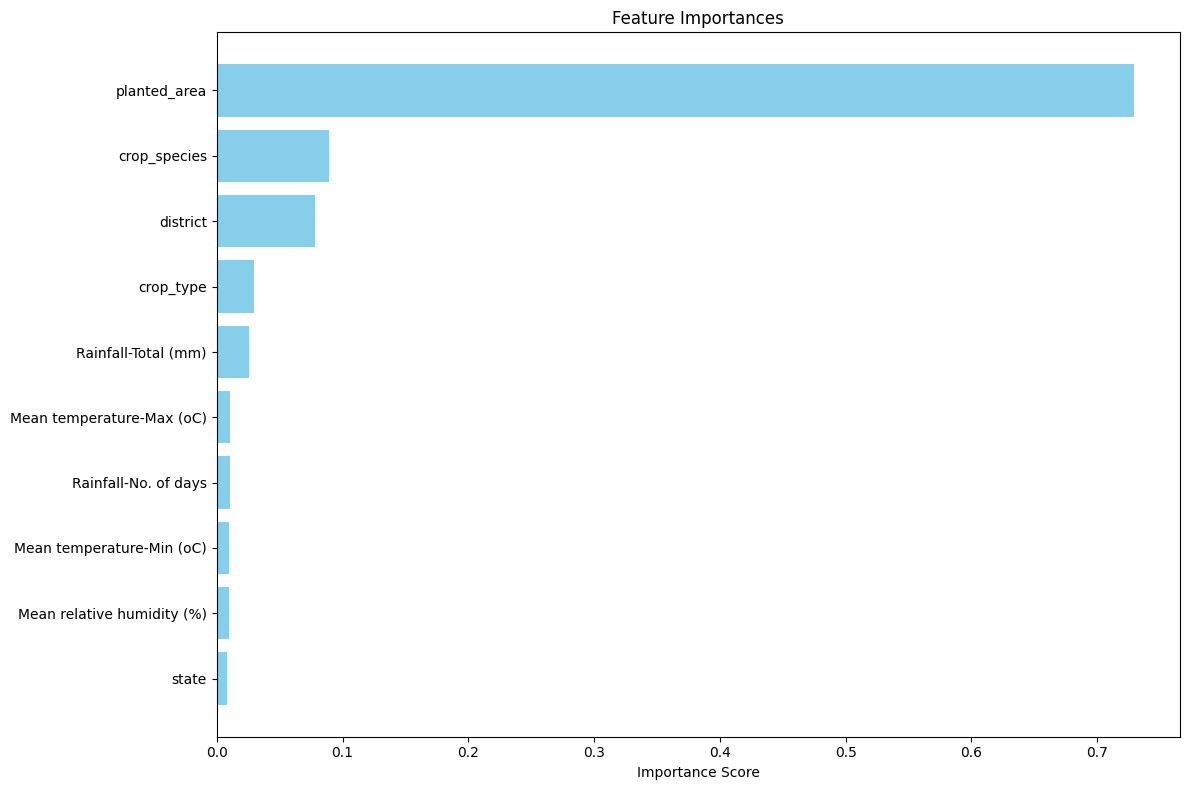

In [ ]:
# Load the data
df = pd.read_csv('minmax_cleaned.csv')

# Prepare features and target
target_column = 'production'
X = df.drop(columns=[target_column, "date"])
y = df[target_column]

# Train Random Forest model
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(random_state=42)
model.fit(X, y)

# Get feature importances
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 8))
plt.barh(feature_importances['Feature'], feature_importances['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.title('Feature Importances')
plt.gca().invert_yaxis()  # Most important features at top
plt.tight_layout()
plt.show()

# Model Selection

Import Library

In [ ]:
!pip install --quiet --upgrade catboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split   # For splitting the dataset into training and test sets
from sklearn.linear_model import LinearRegression          # For applying Linear Regression model
from sklearn.ensemble import VotingRegressor           # For applying Voting Regression model
from sklearn.ensemble import RandomForestRegressor     # For applying Random Forest Regressor (ensemble learning)
from sklearn.tree import DecisionTreeRegressor         # For applying Decision Tree Regression model
from xgboost import XGBRegressor                       # For applying XGBoost Regression model
from catboost import CatBoostRegressor                 # For applying CatBoost Regression model
import lightgbm as lgb                                 # For applying LightGBM Regression model
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, f1_score, accuracy_score  # For evaluating model performance with common regression metrics
from sklearn.preprocessing import StandardScaler       # For feature scaling (standardization)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import KFold
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from scipy.stats import uniform, randint


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.1 MB/s eta 0:00:00


Why choose these models ?
1. **Voting Regressor**
- Combines multiple models to improve overall prediction accuracy.
- Reduces overfitting and increases model robustness.
- Flexible and easy to integrate with different types of regressors.

2. **Random Forest**
- A tree-based ensemble model that reduces overfitting by averaging many decision trees.
- Handles non-linear relationships well.
- Provides feature importance, helping validate relevant features.

3. **Decision Tree**
- A simple, interpretable model that breaks decisions into a flowchart.
- Good for understanding data structure and how features split.
- Lightweight and useful for early-stage analysis.

4. **XGBoost (Extreme Gradient Boosting)**
- Known for high performance and often wins competitions like Kaggle.
- Uses boosting, where each new tree improves the mistakes of previous ones.
- Handles missing data and regularization very well.

5. **CatBoost**
- Automatically handles categorical features efficiently.
- Delivers high performance with fast training and strong accuracy.
- Reduces overfitting with advanced boosting techniques.

6. **LightGBM (Light Gradient Boosting Machine)**
- A gradient boosting algorithm like XGBoost but optimized for speed and memory.
- Performs well with large datasets and high-dimensional features.
- Efficient with categorical variables and feature importance.

# Model Training

## 1.0 Voting Regressor

Voting Regressor is an ensemble technique used in regression tasks that combines the predictions of multiple diverse models by averaging their outputs. This approach leverages the strengths of different algorithms, reducing the risk of relying on a single model’s bias or limitations. As a result, it often leads to better generalization, improved prediction accuracy, and enhanced stability. Voting Regressors are especially useful when individual models perform well in different aspects of the data, making the final prediction more robust and reliable.

### 1.1 Model Training

Split dataset into training and testing data

In [ ]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Train model

📊 Voting Regressor (Enhanced Without Tuning) Metrics:
MAE:       0.0962
MSE:       0.0271
R²:        0.6960
F1 Score:  0.9927


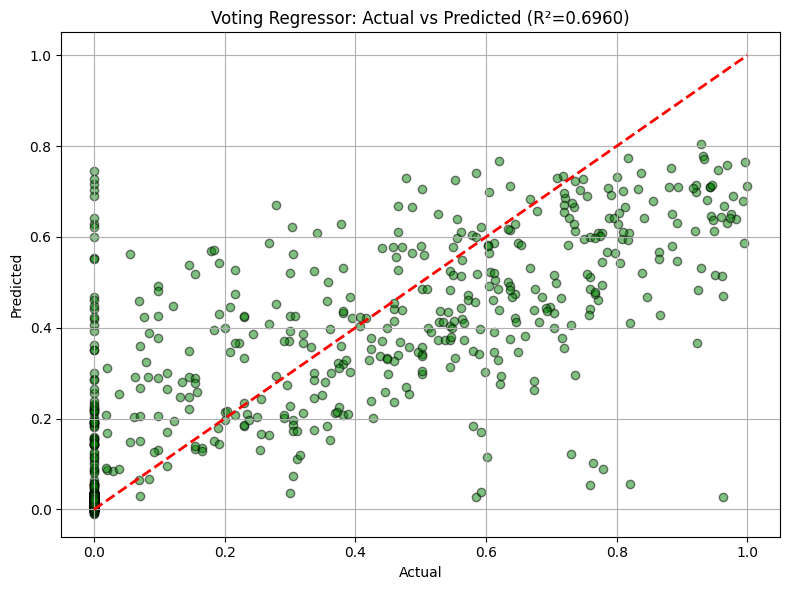

In [ ]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Define improved base regressors
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=150, max_depth=10, random_state=42)
gbr = GradientBoostingRegressor(n_estimators=150, learning_rate=0.08, max_depth=3, random_state=42)

# Voting Regressor
voting_model = VotingRegressor([('lr', lr), ('rf', rf), ('gbr', gbr)])

# Fit model
voting_model.fit(X_train, y_train)

# Predict
y_pred = voting_model.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Classification metrics (based on median threshold)
threshold = np.median(y_test)
y_test_bin = (y_test >= threshold).astype(int)
y_pred_bin = (y_pred >= threshold).astype(int)
acc = accuracy_score(y_test_bin, y_pred_bin)
f1 = f1_score(y_test_bin, y_pred_bin)

# Output
print("📊 Voting Regressor (Enhanced Without Tuning) Metrics:")
print(f"MAE:       {mae:.4f}")
print(f"MSE:       {mse:.4f}")
print(f"R²:        {r2:.4f}")
print(f"F1 Score:  {f1:.4f}")

# Plot actual vs predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='green', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Voting Regressor: Actual vs Predicted (R²={r2:.4f})")
plt.grid(True)
plt.tight_layout()
plt.show()

### 1.2 Hyperparameter Tuning


📊 Voting Regressor Evaluation (Optimized):
MSE:      0.0278
MAE:      0.0976
R²:       0.6885
F1 Score: 0.9932


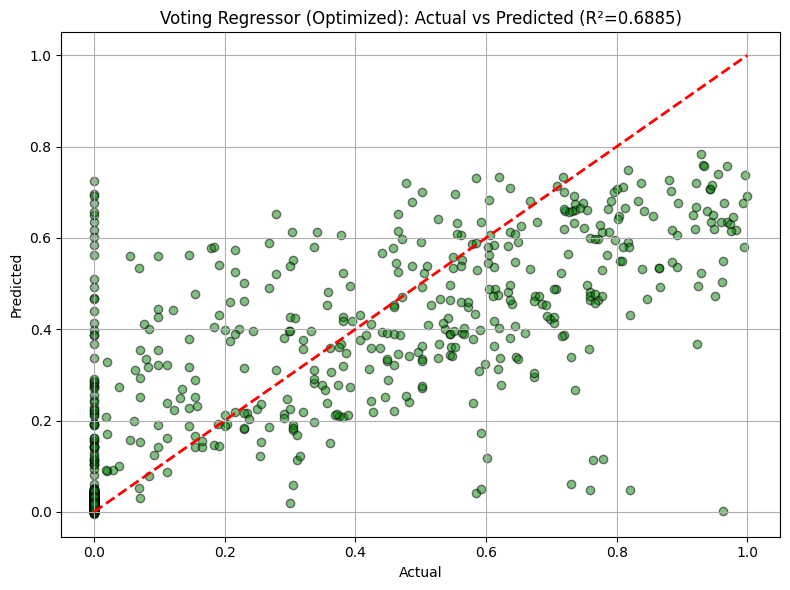

In [ ]:

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define base models
rf = RandomForestRegressor(random_state=42)
gbr = GradientBoostingRegressor(random_state=42)

# Smaller hyperparameter grid for fast search
rf_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10]
}

gbr_param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3]
}

# Grid search for RandomForest
rf_grid = GridSearchCV(rf, rf_param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=0)
rf_grid.fit(X_train_scaled, y_train)
best_rf = rf_grid.best_estimator_

# Grid search for GradientBoosting
gbr_grid = GridSearchCV(gbr, gbr_param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=0)
gbr_grid.fit(X_train_scaled, y_train)
best_gbr = gbr_grid.best_estimator_

# Voting Regressor with tuned estimators
voting_model = VotingRegressor([
    ('lr', LinearRegression()),
    ('rf', best_rf),
    ('gbr', best_gbr)
])
voting_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = voting_model.predict(X_test_scaled)

# Binary classification threshold based on median of y_test
threshold = np.median(y_test)
y_test_bin = (y_test >= threshold).astype(int)
y_pred_bin = (y_pred >= threshold).astype(int)

# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
f1 = f1_score(y_test_bin, y_pred_bin)

# Print results
print("\n📊 Voting Regressor Evaluation (Optimized):")
print(f"MSE:      {mse:.4f}")
print(f"MAE:      {mae:.4f}")
print(f"R²:       {r2:.4f}")
print(f"F1 Score: {f1:.4f}")

# Plot actual vs predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='green', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Voting Regressor (Optimized): Actual vs Predicted (R²={r2:.4f})")
plt.grid(True)
plt.tight_layout()
plt.show()



## 2.0 Random Forest


Random Forest is an ensemble machine learning algorithm used for both classification and regression tasks. It works by building a large number of individual decision trees during training and combining their outputs to make a more accurate and stable prediction. In classification, it takes a majority vote from the trees, while in regression, it averages their predictions. Each tree in the forest is trained on a random subset of the data (using bagging) and considers a random subset of features at each split, which helps reduce overfitting and improves generalization. This randomness makes Random Forest robust, less sensitive to noise, and capable of capturing complex patterns in data. It is widely used due to its high accuracy, ability to handle both numerical and categorical features, and feature importance analysis, which helps identify the most influential variables in prediction.

### 2.1 Model Training


🌲 Random Forest :
MAE:      0.0907
MSE:      0.0268
R²:       0.6991
F1 Score: 1.0000


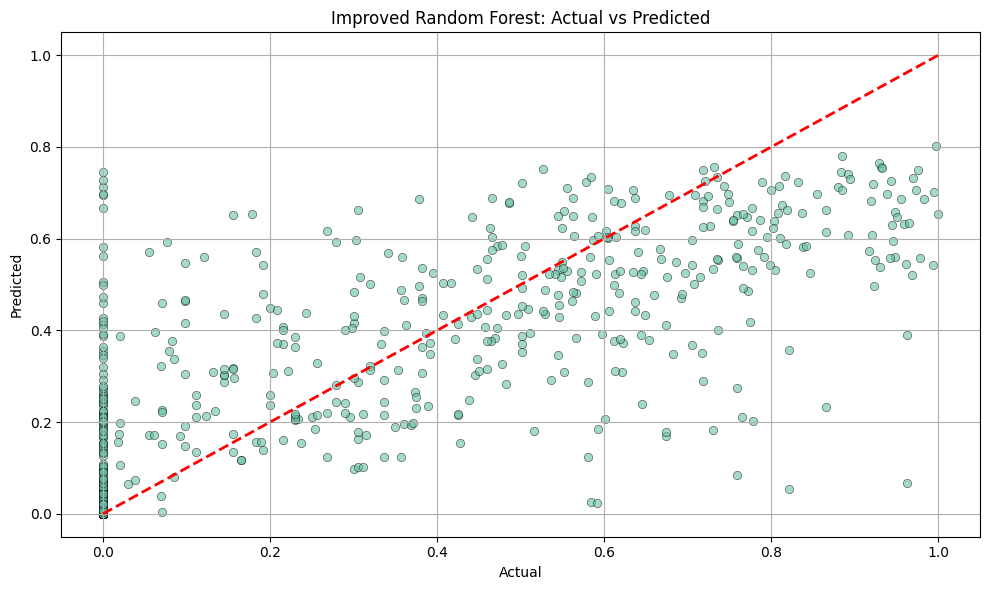

In [ ]:
# Improved Random Forest model (manually enhanced without tuning)
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluation metrics
mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# Accuracy + F1 using binary threshold
threshold = np.median(y_test)
y_test_bin = (y_test >= threshold).astype(int)
y_pred_bin = (y_pred_rf >= threshold).astype(int)
f1_rf = f1_score(y_test_bin, y_pred_bin)

# Print metrics
print("\n🌲 Random Forest :")
print(f"MAE:      {mae_rf:.4f}")
print(f"MSE:      {mse_rf:.4f}")
print(f"R²:       {r2_rf:.4f}")
print(f"F1 Score: {f1_rf:.4f}")

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6, edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Improved Random Forest: Actual vs Predicted')
plt.grid(True)
plt.tight_layout()
plt.show()



### 2.2 Hyperparameter Tuning

Fitting 3 folds for each of 15 candidates, totalling 45 fits

🔍 Random Forest (Optimized) Metrics:
Best Threshold: 0.3055
MAE:            0.0923
MSE:            0.0260
R²:             0.7083
F1 Score:       0.8266


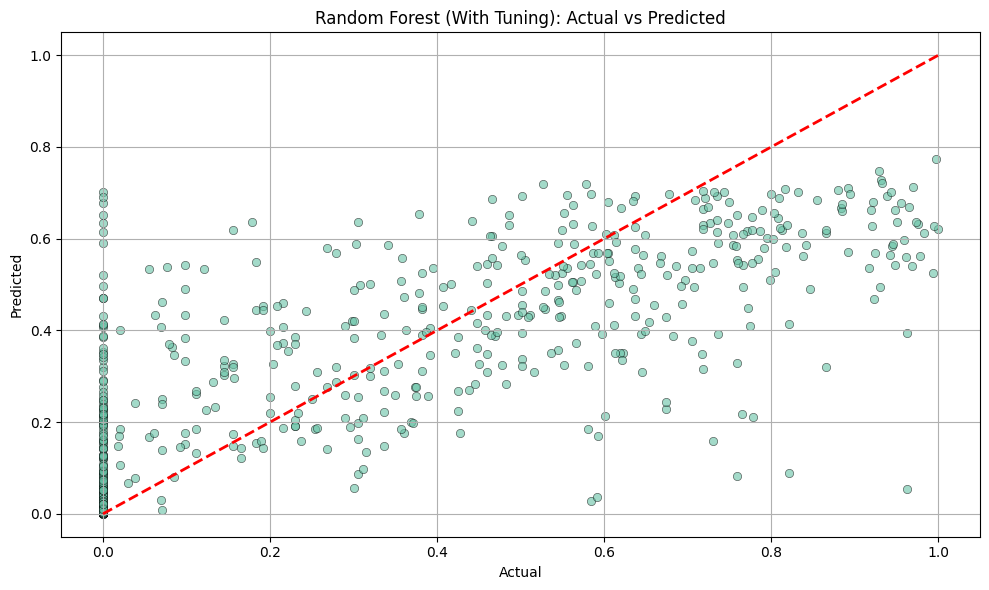

In [ ]:
# STEP 2: Hyperparameter Tuning (Fast & Broad)
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

rf = RandomForestRegressor(random_state=42)

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=15,  # Try 15 random combinations
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train, y_train)
best_rf = random_search.best_estimator_

# Predict
y_pred_rf_tuned = best_rf.predict(X_test)

# Optimal Threshold for F1 (Binary)
# Convert y_test to binary using a meaningful threshold
threshold = np.percentile(y_train, 75)  # e.g., Top 25% = positive class
y_test_bin = (y_test >= threshold).astype(int)

# Try multiple thresholds and select best F1
best_f1 = 0
best_threshold = 0.5
for t in np.linspace(min(y_pred_rf_tuned), max(y_pred_rf_tuned), 100):
    y_pred_bin = (y_pred_rf_tuned >= t).astype(int)
    f1 = f1_score(y_test_bin, y_pred_bin)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

# Final binary predictions
y_pred_bin_tuned = (y_pred_rf_tuned >= best_threshold).astype(int)

# STEP 5: Evaluation
mse_rf_tuned = mean_squared_error(y_test, y_pred_rf_tuned)
mae_rf_tuned = mean_absolute_error(y_test, y_pred_rf_tuned)
r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)
f1 = f1_score(y_test_bin, y_pred_bin_tuned)

# Results
print("\n🔍 Random Forest (Optimized) Metrics:")
print(f"Best Threshold: {best_threshold:.4f}")
print(f"MAE:            {mae_rf_tuned:.4f}")
print(f"MSE:            {mse_rf_tuned:.4f}")
print(f"R²:             {r2_rf_tuned:.4f}")
print(f"F1 Score:       {f1:.4f}")

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_rf_tuned, alpha=0.6, edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Random Forest (With Tuning): Actual vs Predicted')
plt.grid(True)
plt.tight_layout()
plt.show()


## 3.0 Decision Tree

A decision tree is a machine learning model that makes predictions by learning decision rules from the data. It structures these rules in a tree-like format, where each internal node represents a test on a feature, each branch represents the result of the test, and each leaf node gives a final output or prediction. The model splits the data into subsets based on feature values to reduce uncertainty or error, aiming to create the most informative separations. It's commonly used for both classification and regression tasks

### 3.1 Model Trainning

📊 Decision Tree (Tuned) Metrics:
MAE:      0.0990
MSE:      0.0320
R²:       0.6414
F1 Score: 0.7828


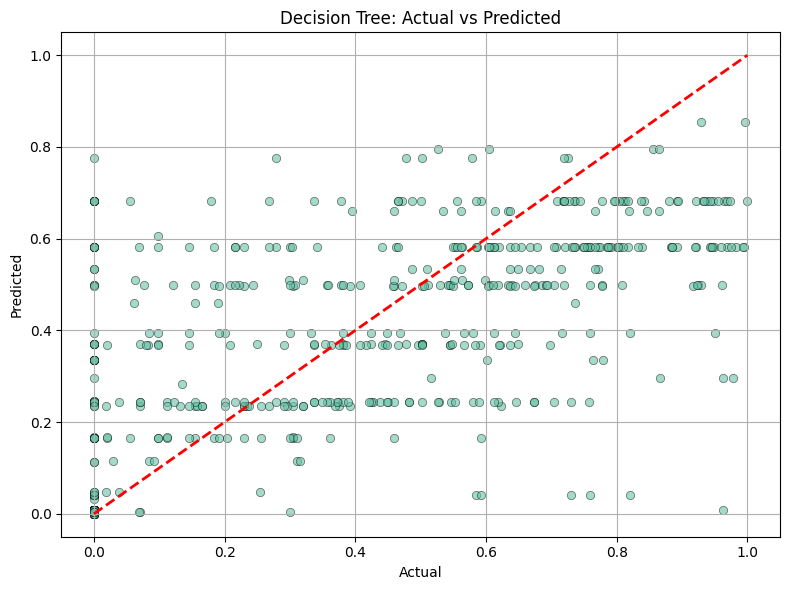

In [ ]:
dt_model = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_test)

# Binary threshold for F1
threshold = np.percentile(y_train, 75)
y_test_bin = (y_test >= threshold).astype(int)
y_pred_bin = (y_pred >= threshold).astype(int)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
f1 = f1_score(y_test_bin, y_pred_bin)

print("📊 Decision Tree (Tuned) Metrics:")
print(f"MAE:      {mae:.4f}")
print(f"MSE:      {mse:.4f}")
print(f"R²:       {r2:.4f}")
print(f"F1 Score: {f1:.4f}")

# 6. Plot Actual vs Predicted
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Decision Tree: Actual vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

### 3.2 Hyperparameter Tuning


📊 Decision Tree (With Tuning) Metrics:
Best Threshold for Binary Classification: 0.2415
MAE:      0.0992
MSE:      0.0320
R²:       0.6403
F1 Score: 0.8101


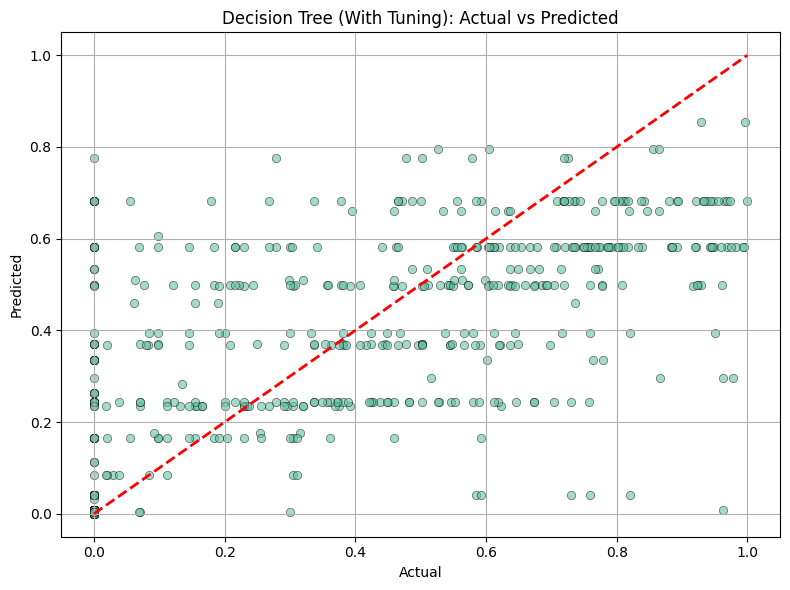

In [ ]:
#  Parameter Tuning with GridSearchCV
param_grid = {
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)
best_dt = grid_search.best_estimator_


# Prediction
y_pred_tuned = best_dt.predict(X_test)


#  Smart Threshold Tuning to Maximize F1 Score
# Define binary target from y_test
threshold_true = np.percentile(y_train, 75)  # use 75th percentile for class 1
y_test_bin = (y_test >= threshold_true).astype(int)

# Find best threshold for predicted values
best_f1 = 0
best_threshold = threshold_true
for t in np.linspace(min(y_pred_tuned), max(y_pred_tuned), 100):
    y_pred_bin_tuned = (y_pred_tuned >= t).astype(int)
    f1 = f1_score(y_test_bin, y_pred_bin_tuned)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

# Final binary predictions
y_pred_bin_final = (y_pred_tuned >= best_threshold).astype(int)


# Evaluation Metrics
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)
f1_final = f1_score(y_test_bin, y_pred_bin_final)

print("\n📊 Decision Tree (With Tuning) Metrics:")
print(f"Best Threshold for Binary Classification: {best_threshold:.4f}")
print(f"MAE:      {mae_tuned:.4f}")
print(f"MSE:      {mse_tuned:.4f}")
print(f"R²:       {r2_tuned:.4f}")
print(f"F1 Score: {f1_final:.4f}")


#  Visualization
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_tuned, alpha=0.6, edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Decision Tree (With Tuning): Actual vs Predicted')
plt.grid(True)
plt.tight_layout()
plt.show()


## 4.0 XGBoost (Extreme Gradient Boosting)

XGBoost is a machine learning algorithm that uses gradient boosting to build a strong predictive model from an ensemble of weaker models, typically decision trees. It improves accuracy by learning from the mistakes of previous models in a sequential manner. XGBoost includes regularization to prevent overfitting and is optimized for speed and efficiency, making it suitable for large datasets and competitive machine learning tasks.










### 4.1 Model Training

In [ ]:
# Install XGBoost if not already installed
!pip install xgboost

XGBoost (Without Tuning) Metrics:
MAE:      0.0955
MSE:      0.0320
R²:       0.6412
F1:       0.8514


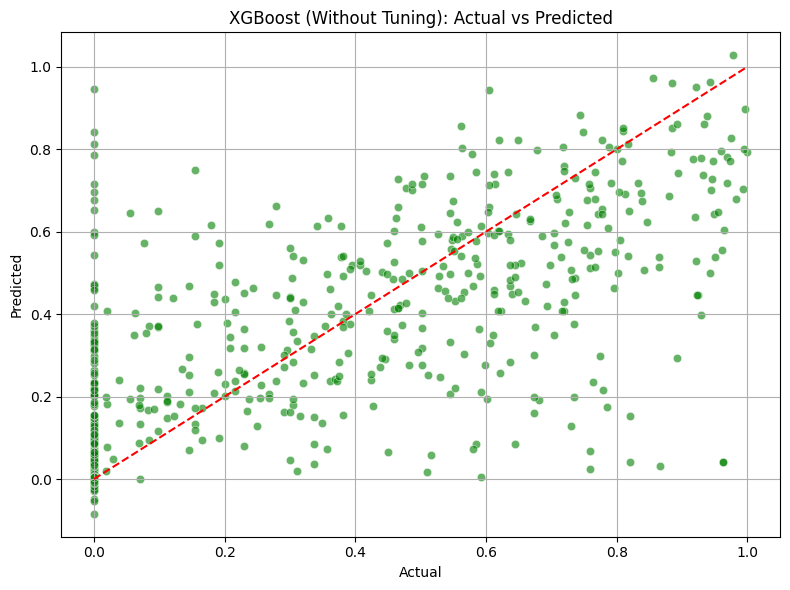

In [ ]:
# Train XGBoost with default parameters
xgb_model = XGBRegressor(random_state=42, verbosity=0)
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

# Accuracy threshold (median-based)
threshold = np.median(y_test)
y_test_bin = (y_test >= threshold).astype(int)
y_pred_bin = (y_pred >= threshold).astype(int)


# Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
f1 = f1_score(y_test_bin, y_pred_bin)

print("XGBoost (Without Tuning) Metrics:")
print(f"MAE:      {mae:.4f}")
print(f"MSE:      {mse:.4f}")
print(f"R²:       {r2:.4f}")
print(f"F1:       {f1:.4f}")

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("XGBoost (Without Tuning): Actual vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()


### 4.2 Hyperparameter Tuning

Fitting 3 folds for each of 20 candidates, totalling 60 fits

XGBoost (With Tuning) Metrics:
MAE:      0.0931
MSE:      0.0262
R²:       0.7065
F1 Score: 0.9461


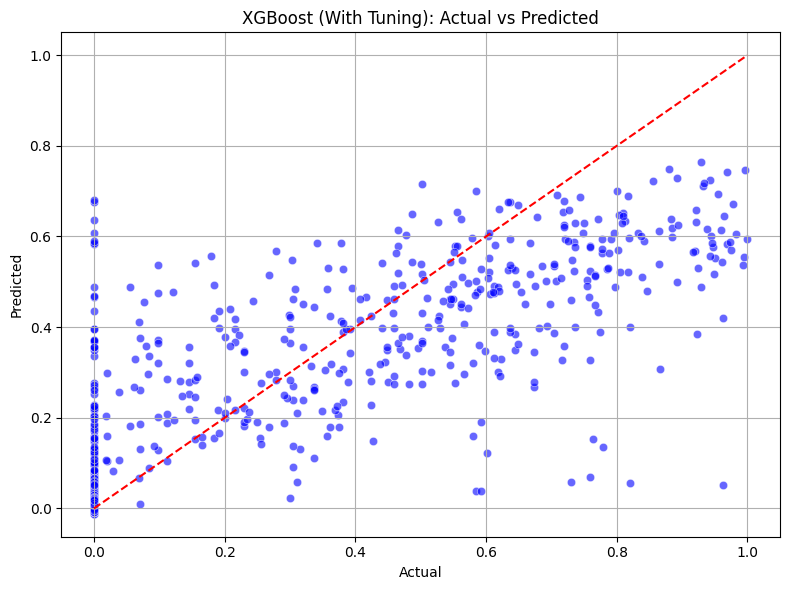

In [ ]:
# Log transform target
y_log = np.log1p(y)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Train-test split
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X_scaled, y_log, test_size=0.2, random_state=42
)

# Define parameter distribution for RandomizedSearch
param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 7),
    'learning_rate': uniform(0.01, 0.1),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
}

xgb = XGBRegressor(random_state=42, verbosity=0)

# Randomized Search with 20 iterations (fast)
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='neg_mean_squared_error',
    random_state=42,
    verbose=1,
    n_jobs=-1
)

random_search.fit(X_train, y_train_log)


best_model = random_search.best_estimator_

y_pred_log = best_model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_test = np.expm1(y_test_log)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

threshold = np.median(y_test)
y_test_bin = (y_test >= threshold).astype(int)
y_pred_bin = (y_pred >= threshold).astype(int)

f1 = f1_score(y_test_bin, y_pred_bin)

print("\nXGBoost (With Tuning) Metrics:")
print(f"MAE:      {mae:.4f}")
print(f"MSE:      {mse:.4f}")
print(f"R²:       {r2:.4f}")
print(f"F1 Score: {f1:.4f}")

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("XGBoost (With Tuning): Actual vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()


## 5.0 CatBoost

### 5.1 Model Training

In [ ]:
# Install catboost if not installed
!pip install --quiet --upgrade catboost

CatBoost (Without Tuning) Metrics:
MAE:      0.0877
MSE:      0.0258
R²:       0.7106
F1 Score: 0.8634


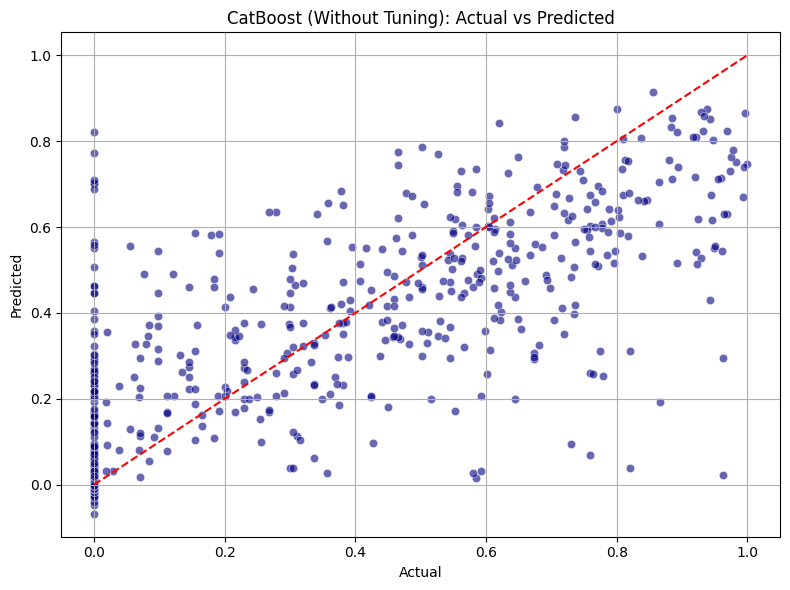

In [ ]:
# Train CatBoost (default)
model = CatBoostRegressor(verbose=0, random_seed=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Accuracy threshold based on median
threshold = np.median(y_test)
y_test_bin = (y_test >= threshold).astype(int)
y_pred_bin = (y_pred >= threshold).astype(int)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
f1 = f1_score(y_test_bin, y_pred_bin)

print("CatBoost (Without Tuning) Metrics:")
print(f"MAE:      {mae:.4f}")
print(f"MSE:      {mse:.4f}")
print(f"R²:       {r2:.4f}")
print(f"F1 Score: {f1:.4f}")

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='navy')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('CatBoost (Without Tuning): Actual vs Predicted')
plt.grid(True)
plt.tight_layout()
plt.show()


### 5.2 Hyperparameter Tuning


CatBoost (With Tuning) Metrics:
Best Params: {'depth': 4, 'iterations': 200, 'learning_rate': 0.1}
MAE:         0.0884
MSE:         0.0254
R²:          0.7149
F1:          0.8634


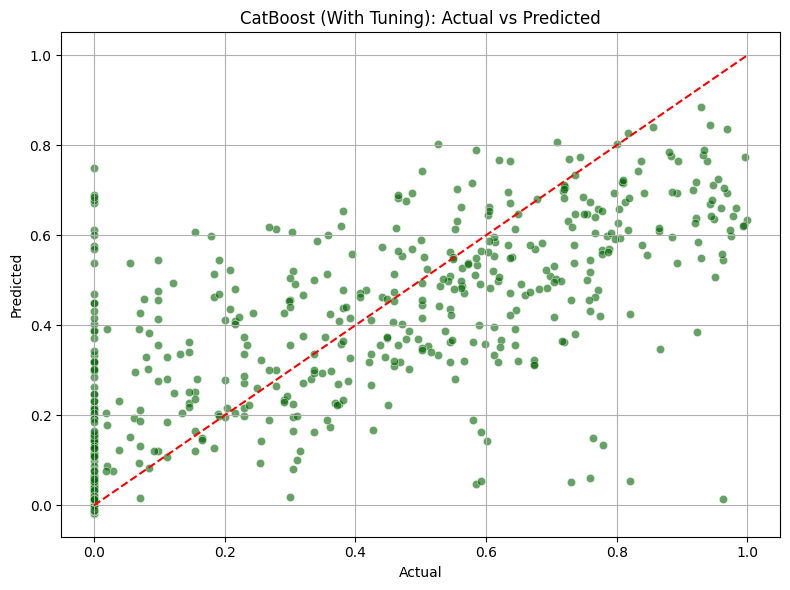

In [ ]:
# Define parameter grid
param_grid = {
    'depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'iterations': [100, 200]
}

# Initialize model for tuning
cat_model = CatBoostRegressor(verbose=0, random_seed=42)

# Grid search
grid = GridSearchCV(cat_model, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid.fit(X_train, y_train)

# Best estimator
best_model = grid.best_estimator_
y_pred_tuned = best_model.predict(X_test)

# Accuracy threshold
y_pred_bin_tuned = (y_pred_tuned >= threshold).astype(int)

# Evaluation metrics
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)
f1 = f1_score(y_test_bin, y_pred_bin)

print("\nCatBoost (With Tuning) Metrics:")
print(f"Best Params: {grid.best_params_}")
print(f"MAE:         {mae_tuned:.4f}")
print(f"MSE:         {mse_tuned:.4f}")
print(f"R²:          {r2_tuned:.4f}")
print(f"F1:          {f1:.4f}")

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_tuned, alpha=0.6, color='darkgreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('CatBoost (With Tuning): Actual vs Predicted')
plt.grid(True)
plt.tight_layout()
plt.show()


## 6.0 LightGBM (Light Gradient Boosting Machine)

### 6.1 Model Training

LightGBM is a boosting algorithm designed for speed and efficiency in machine learning tasks, especially for large datasets. It works by creating multiple decision trees sequentially, with each tree correcting the errors of the previous one.
Key Features:
- Uses Gradient Boosting, meaning it minimizes errors by learning iteratively.
- Employs leaf-wise growth, making it faster than traditional depth-wise tree models.
- Handles large datasets efficiently and supports categorical features natively.

LightGBM is widely used in classification and regression problems, especially in competitions like Kaggle due to its speed and accuracy.


In [ ]:
!pip install lightgbm

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000999 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 594
[LightGBM] [Info] Number of data points in the train set: 4144, number of used features: 10
[LightGBM] [Info] Start training from score 0.178447
LightGBM Results:
MAE:       0.0880
MSE:       0.0263
R² Score:  0.7043
F1 Score:  0.8151


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


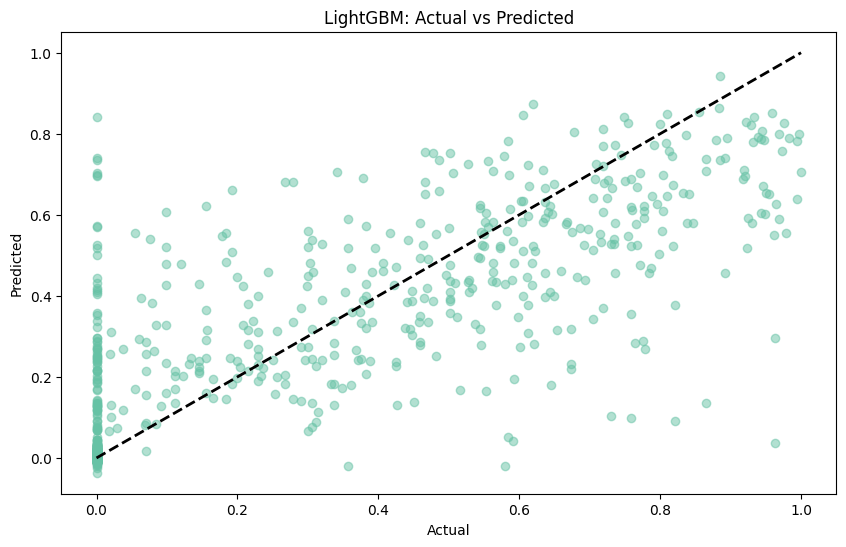

In [ ]:
# LightGBM model
lgb_model = lgb.LGBMRegressor(random_state=42)
lgb_model.fit(X_train, y_train)

# Prediction
y_pred = lgb_model.predict(X_test)


# Evaluation
mae_gbm = mean_absolute_error(y_test, y_pred)
mse_gbm = mean_squared_error(y_test, y_pred)
r2_gbm = r2_score(y_test, y_pred)

# Binary classification setup
threshold = np.percentile(y_train, 75)  # or use np.median(y_train)
y_test_bin = (y_test >= threshold).astype(int)
y_pred_bin = (y_pred >= threshold).astype(int)
f1_gbm = f1_score(y_test_bin, y_pred_bin)

# Print results
print("LightGBM Results:")
print(f"MAE:       {mae_gbm:.4f}")
print(f"MSE:       {mse_gbm:.4f}")
print(f"R² Score:  {r2_gbm:.4f}")
print(f"F1 Score:  {f1_gbm:.4f}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('LightGBM: Actual vs Predicted')
plt.show()

### 6.2 Hyperparameter Tuning

Fitting 3 folds for each of 54 candidates, totalling 162 fits


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000313 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 594
[LightGBM] [Info] Number of data points in the train set: 4144, number of used features: 10
[LightGBM] [Info] Start training from score 0.178447
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

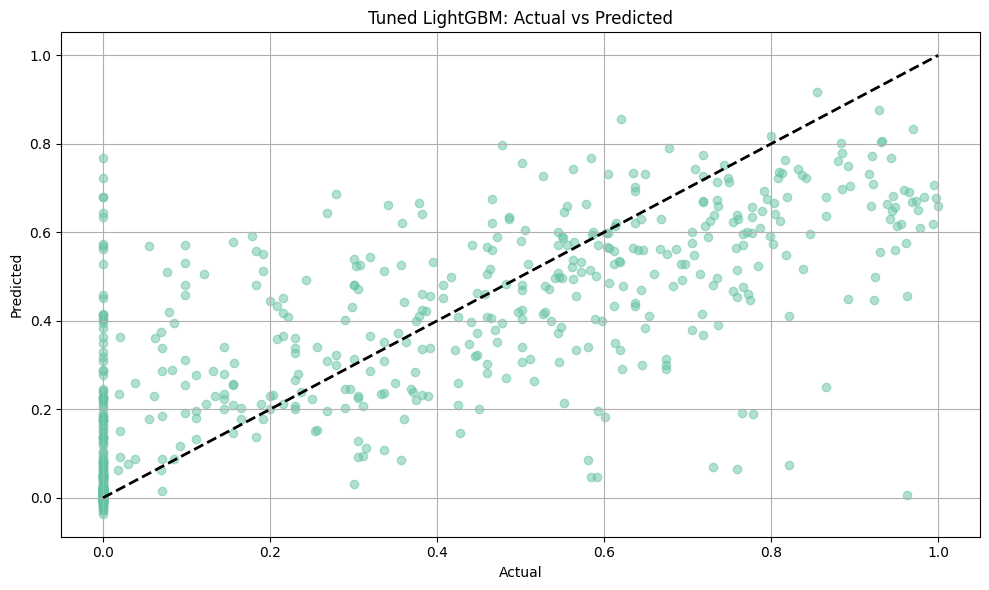

In [ ]:
# Define LightGBM model
lgb_model = lgb.LGBMRegressor(random_state=42)

# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'num_leaves': [15, 31, 63]
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=lgb_model,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Fit model
grid_search.fit(X_train, y_train)

# Best model
best_model = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

# Predict
y_pred = best_model.predict(X_test)

# Evaluation: Regression
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Binary classification setup for F1 Score
threshold = np.percentile(y_train, 75)  # top 25% as class 1
y_test_bin = (y_test >= threshold).astype(int)
y_pred_bin = (y_pred >= threshold).astype(int)
f1 = f1_score(y_test_bin, y_pred_bin)

# Print metrics
print("\n📊 Tuned LightGBM Results:")
print(f"MAE:       {mae:.4f}")
print(f"MSE:       {mse:.4f}")
print(f"R² Score:  {r2:.4f}")
print(f"F1 Score:  {f1:.4f}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Tuned LightGBM: Actual vs Predicted')
plt.grid(True)
plt.tight_layout()
plt.show()


#Model Evaluation

## Comparison of 6 Models

Use metrics **R-Squared** to evaluate and compare the model performances:

- The **higher** the value of R-Squared, the better the performance of model.

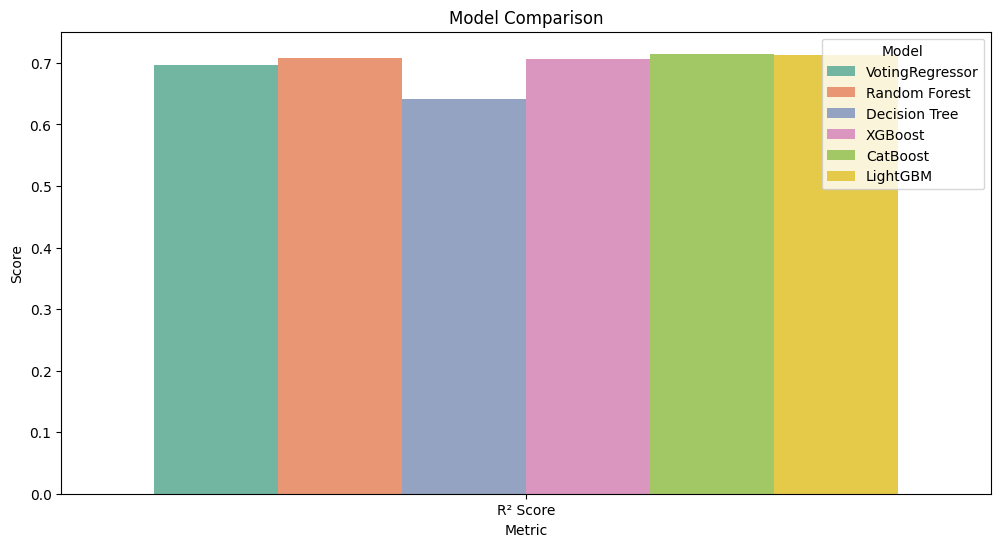

     Metric  VotingRegressor  Random Forest  Decision Tree  XGBoost  CatBoost  \
0  R² Score            0.696         0.7083         0.6414   0.7065    0.7149   

   LightGBM  
0    0.7127  


In [ ]:
# Create a comparison dataframe
comparison = pd.DataFrame({
    'Metric': ['R² Score'],
    'VotingRegressor': [0.6960],
    'Random Forest': [0.7083],
    'Decision Tree': [0.6414],
    'XGBoost': [0.7065],
    'CatBoost': [0.7149],
    'LightGBM': [0.7127],
})

# Melt for visualization
comparison_melted = comparison.melt(id_vars='Metric', var_name='Model', value_name='Score')

# Plot comparison
plt.figure(figsize=(12, 6))
sns.barplot(x='Metric', y='Score', hue='Model', data=comparison_melted)
plt.title('Model Comparison')
plt.show()

print(comparison)

# Conclusion

CatBoost is the best model since it has the highest value of R² (0.7149) compare to other models.